# 06 — Model Optimization

This notebook extends the baseline predictive modeling established in Notebook 05.

The objective is to determine whether controlled model optimization can improve 30-day hospital readmission prediction while preserving the methodological safeguards established earlier in the project.

Notebook 05 established a locked baseline using:

- random forest as the primary screening model;
- standard logistic regression as a probability-reference model;
- validation-only model and threshold selection;
- a selected random-forest operating threshold of 0.44;
- final evaluation on an untouched held-out test partition.

Notebook 06 will improve upon that baseline using structured model development rather than unrestricted experimentation.

The optimization process will include:

1. cross-validation within the development data;
2. constrained hyperparameter optimization;
3. comparison of additional ensemble methods;
4. probability-calibration assessment;
5. threshold optimization under the screening objective;
6. final model selection using development data only; and
7. one final evaluation on the locked held-out test partition.

The held-out test partition will remain excluded from all model-selection decisions until the final candidate model and operating threshold have been fixed.

## 6A — Optimization Objective & Guardrails

The primary modeling objective remains identification of encounters at elevated risk of 30-day hospital readmission.

Because readmission represents a minority outcome, model optimization will not be driven by raw accuracy. Candidate models will instead be assessed using complementary measures of:

- discrimination;
- precision-recall performance;
- probability quality;
- sensitivity;
- specificity;
- balanced accuracy; and
- threshold-dependent operating characteristics.

The principal optimization objective is to improve discrimination and minority-class detection relative to the Notebook 05 baseline while avoiding substantial degradation in probability quality or model stability.

### Development guardrails

The following safeguards apply throughout Notebook 06:

- training data may be used for fitting and cross-validation;
- validation data may be used for final development-stage comparison;
- test data must not influence hyperparameter selection;
- test data must not influence calibration-method selection;
- test data must not influence threshold selection;
- preprocessing must remain fitted exclusively from the original training partition;
- feature definitions established in Notebook 04 must remain unchanged unless explicitly justified;
- the Notebook 05 baseline remains the reference benchmark.

Only after the final optimized model and operating threshold are locked will the held-out test partition be evaluated.

In [1]:
# Core imports for controlled model optimization

from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Random state: {RANDOM_STATE}")
print(f"Pandas version: {pd.__version__}")

Random state: 42
Pandas version: 3.0.5


## 6B — Load Baseline Artifacts

Notebook 05 established the reference baseline against which optimized models will be evaluated.

Rather than manually reproducing baseline values, this section loads the persisted modeling artifacts created by the completed baseline pipeline. This preserves consistency between notebooks and reduces the risk of silently changing previously established model-selection decisions.

The following artifacts are loaded:

- the fitted preprocessing transformer;
- the fitted baseline random forest;
- the fitted standard logistic-regression reference model;
- baseline model metadata;
- baseline model-selection results; and
- final held-out baseline test results.

The held-out test results are loaded strictly as a historical benchmark. They will not be used to select or tune candidate models in Notebook 06.

In [2]:
# Resolve project directories and baseline artifact paths

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.joblib"
BASELINE_RF_PATH = MODELS_DIR / "random_forest_baseline.joblib"
BASELINE_LOGISTIC_PATH = MODELS_DIR / "standard_logistic_baseline.joblib"

BASELINE_METADATA_PATH = REPORTS_DIR / "baseline_model_metadata.json"
BASELINE_SELECTION_PATH = REPORTS_DIR / "baseline_model_selection_summary.csv"
BASELINE_TEST_RESULTS_PATH = REPORTS_DIR / "baseline_final_test_results.csv"

required_artifacts = [
    PREPROCESSOR_PATH,
    BASELINE_RF_PATH,
    BASELINE_LOGISTIC_PATH,
    BASELINE_METADATA_PATH,
    BASELINE_SELECTION_PATH,
    BASELINE_TEST_RESULTS_PATH,
]

missing_artifacts = [path for path in required_artifacts if not path.exists()]

if missing_artifacts:
    raise FileNotFoundError(
        "Required baseline artifacts are missing:\n"
        + "\n".join(str(path) for path in missing_artifacts)
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Required baseline artifacts verified: {len(required_artifacts)}")

Project root: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics
Required baseline artifacts verified: 6


In [3]:
# Load persisted Notebook 04/05 modeling artifacts

preprocessor = joblib.load(PREPROCESSOR_PATH)
baseline_random_forest = joblib.load(BASELINE_RF_PATH)
baseline_logistic = joblib.load(BASELINE_LOGISTIC_PATH)

with open(
    BASELINE_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    baseline_metadata = json.load(file)

baseline_selection_summary = pd.read_csv(BASELINE_SELECTION_PATH)

baseline_test_results = pd.read_csv(BASELINE_TEST_RESULTS_PATH)

print("BASELINE ARTIFACTS LOADED")
print("=" * 70)

print(f"Selected model:       {baseline_metadata['selected_model']}")
print(f"Locked threshold:     {baseline_metadata['selected_threshold']:.4f}")
print(
    "Target sensitivity:  " f"{baseline_metadata['target_validation_sensitivity']:.2f}"
)
print(
    "Probability reference:",
    baseline_metadata["probability_reference_model"],
)

print(f"\nSelection-summary rows: {len(baseline_selection_summary):,}")
print(f"Final-test result rows: {len(baseline_test_results):,}")

print("\n✓ Notebook 05 baseline state recovered successfully.")

BASELINE ARTIFACTS LOADED
Selected model:       Random forest
Locked threshold:     0.4400
Target sensitivity:  0.70
Probability reference: Standard logistic regression

Selection-summary rows: 4
Final-test result rows: 2

✓ Notebook 05 baseline state recovered successfully.


In [4]:
# Inspect persisted processed-data artifacts before reconstruction

processed_files = sorted(
    path.relative_to(PROJECT_ROOT)
    for path in PROCESSED_DIR.rglob("*")
    if path.is_file()
)

print("PROCESSED DATA ARTIFACTS")
print("=" * 70)

for path in processed_files:
    print(path)

print(f"\nTotal processed-data files: {len(processed_files)}")

PROCESSED DATA ARTIFACTS
data\processed\feature_registry.json
data\processed\test.csv
data\processed\train.csv
data\processed\validation.csv

Total processed-data files: 4


## 6C — Reconstruct Development Matrices

Load the persisted train, validation, and held-out test partitions created during preprocessing.

Model optimization is restricted to the training and validation partitions. The held-out test partition remains isolated until a final optimized model and operating threshold have been selected.

In [5]:
# Load persisted train / validation / test partitions

TRAIN_PATH = PROCESSED_DIR / "train.csv"
VALIDATION_PATH = PROCESSED_DIR / "validation.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("PERSISTED DATA PARTITIONS LOADED")
print("=" * 70)

print(f"Train shape:      {train_df.shape}")
print(f"Validation shape: {validation_df.shape}")
print(f"Test shape:       {test_df.shape}")

print("\nTotal rows:", len(train_df) + len(validation_df) + len(test_df))

PERSISTED DATA PARTITIONS LOADED
Train shape:      (71520, 48)
Validation shape: (15027, 48)
Test shape:       (15219, 48)

Total rows: 101766


In [6]:
# Verify partition schemas and identify modeling target

TARGET = "readmitted_30d"

assert TARGET in train_df.columns
assert TARGET in validation_df.columns
assert TARGET in test_df.columns

assert list(train_df.columns) == list(validation_df.columns)
assert list(train_df.columns) == list(test_df.columns)

print("PARTITION SCHEMA VERIFICATION")
print("=" * 70)

print(f"Target: {TARGET}")
print(f"Columns per partition: {train_df.shape[1]}")
print("Train / validation / test schemas identical: YES")

print("\nTarget distributions:")

for partition_name, frame in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    counts = frame[TARGET].value_counts(dropna=False).sort_index()
    rates = (
        frame[TARGET]
        .value_counts(
            normalize=True,
            dropna=False,
        )
        .sort_index()
    )

    print(f"\n{partition_name}:")
    print(
        pd.DataFrame(
            {
                "count": counts,
                "proportion": rates,
            }
        ).round(4)
    )

PARTITION SCHEMA VERIFICATION
Target: readmitted_30d
Columns per partition: 48
Train / validation / test schemas identical: YES

Target distributions:

Train:
                count  proportion
readmitted_30d                   
0               63499      0.8878
1                8021      0.1122

Validation:
                count  proportion
readmitted_30d                   
0               13371      0.8898
1                1656      0.1102

Test:
                count  proportion
readmitted_30d                   
0               13539      0.8896
1                1680      0.1104


In [7]:
# Load persisted Notebook 04 feature registry

FEATURE_REGISTRY_PATH = PROCESSED_DIR / "feature_registry.json"

if not FEATURE_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Required feature registry not found: {FEATURE_REGISTRY_PATH}"
    )

with open(
    FEATURE_REGISTRY_PATH,
    "r",
    encoding="utf-8",
) as file:
    feature_registry = json.load(file)

assert isinstance(feature_registry, dict)
assert "model_features" in feature_registry

print("FEATURE REGISTRY LOADED")
print("=" * 70)
print(f"Model features: {len(feature_registry['model_features'])}")
print("\n✓ Persisted feature registry recovered.")

FEATURE REGISTRY LOADED
Model features: 44

✓ Persisted feature registry recovered.


In [8]:
# Reconstruct Notebook 04/05 candidate predictor matrices exactly

MODEL_FEATURES = feature_registry["model_features"]

X_train = train_df[MODEL_FEATURES].copy()
y_train = train_df[TARGET].astype(int)

X_validation = validation_df[MODEL_FEATURES].copy()
y_validation = validation_df[TARGET].astype(int)

# Keep test loaded for final evaluation only; do not use it for model selection.
X_test = test_df[MODEL_FEATURES].copy()
y_test = test_df[TARGET].astype(int)

assert list(X_train.columns) == list(X_validation.columns)
assert list(X_train.columns) == list(X_test.columns)

assert len(X_train) == len(y_train)
assert len(X_validation) == len(y_validation)
assert len(X_test) == len(y_test)

assert X_train.shape[1] == 44

print("CANDIDATE MODEL MATRICES RECONSTRUCTED")
print("=" * 70)

print(f"X_train:      {X_train.shape} | y_train:      {y_train.shape}")
print(f"X_validation: {X_validation.shape} | y_validation: {y_validation.shape}")
print(f"X_test:       {X_test.shape} | y_test:       {y_test.shape}")

print(f"\nCandidate predictor count: {X_train.shape[1]}")
print("\n✓ Notebook 04/05 44-predictor candidate space recovered.")
print("✓ Held-out test partition remains unavailable for model selection.")

CANDIDATE MODEL MATRICES RECONSTRUCTED
X_train:      (71520, 44) | y_train:      (71520,)
X_validation: (15027, 44) | y_validation: (15027,)
X_test:       (15219, 44) | y_test:       (15219,)

Candidate predictor count: 44

✓ Notebook 04/05 44-predictor candidate space recovered.
✓ Held-out test partition remains unavailable for model selection.


## 6D — Optimization Evaluation Framework

Define a consistent validation framework for comparing candidate models during optimization.

Because 30-day readmission is an imbalanced outcome, model assessment emphasizes ranking and screening performance rather than raw accuracy. ROC-AUC and average precision measure discrimination, while sensitivity, specificity, precision, F1, balanced accuracy, and Brier score characterize operating-point and probability performance.

Model and threshold selection will use the validation partition only. The held-out test partition remains excluded from all optimization decisions.

In [9]:
# Define reusable binary-classification evaluation function


def evaluate_probabilities(
    y_true,
    y_probability,
    threshold=0.50,
):
    y_true = np.asarray(y_true)
    y_probability = np.asarray(y_probability)

    if y_true.shape[0] != y_probability.shape[0]:
        raise ValueError("y_true and y_probability must have equal length.")

    if np.isnan(y_probability).any():
        raise ValueError("Predicted probabilities contain NaN values.")

    if ((y_probability < 0) | (y_probability > 1)).any():
        raise ValueError("Predicted probabilities must lie in [0, 1].")

    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(
            y_true,
            y_probability,
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_probability,
        ),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


print("✓ Validation evaluation function defined.")

✓ Validation evaluation function defined.


In [10]:
# Define validation-only threshold search


def evaluate_threshold_grid(
    y_true,
    y_probability,
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.round(
            np.arange(0.01, 1.00, 0.01),
            2,
        )

    records = []

    for threshold in thresholds:
        metrics = evaluate_probabilities(
            y_true=y_true,
            y_probability=y_probability,
            threshold=threshold,
        )
        records.append(metrics)

    return pd.DataFrame(records)


def select_screening_threshold(
    threshold_results,
    target_sensitivity=0.70,
):
    eligible = threshold_results[
        threshold_results["sensitivity"] >= target_sensitivity
    ].copy()

    if eligible.empty:
        raise ValueError("No threshold satisfies the target sensitivity.")

    # Among thresholds meeting the sensitivity constraint,
    # maximize specificity; break ties using balanced accuracy.
    selected = eligible.sort_values(
        ["specificity", "balanced_accuracy", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]

    return selected


print("✓ Validation threshold-search functions defined.")

✓ Validation threshold-search functions defined.


## 6E — Recover Baseline Validation Reference

Re-evaluate the persisted Notebook 05 random-forest baseline on the validation partition.

This establishes the optimization reference using the same persisted preprocessing pipeline and development data. The held-out test partition is not evaluated in this stage.

In [11]:
# Reconstruct Notebook 04 deterministic clinical feature engineering


def map_icd9_family(code):
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip()

    if code in {"?", "", "nan", "None"}:
        return "Unknown"

    # ICD-9 V and E codes
    if code.startswith("V"):
        return "Supplementary factors"

    if code.startswith("E"):
        return "External causes"

    # Use the integer portion before any decimal
    try:
        numeric_code = int(float(code))
    except ValueError:
        return "Other / Unclassified"

    if 1 <= numeric_code <= 139:
        return "Infectious & parasitic"
    elif 140 <= numeric_code <= 239:
        return "Neoplasms"
    elif 240 <= numeric_code <= 279:
        return "Endocrine, nutritional & metabolic"
    elif 280 <= numeric_code <= 289:
        return "Blood disorders"
    elif 290 <= numeric_code <= 319:
        return "Mental disorders"
    elif 320 <= numeric_code <= 389:
        return "Nervous system & sense organs"
    elif 390 <= numeric_code <= 459:
        return "Circulatory"
    elif 460 <= numeric_code <= 519:
        return "Respiratory"
    elif 520 <= numeric_code <= 579:
        return "Digestive"
    elif 580 <= numeric_code <= 629:
        return "Genitourinary"
    elif 630 <= numeric_code <= 679:
        return "Pregnancy & childbirth"
    elif 680 <= numeric_code <= 709:
        return "Skin & subcutaneous tissue"
    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal & connective tissue"
    elif 740 <= numeric_code <= 759:
        return "Congenital anomalies"
    elif 760 <= numeric_code <= 779:
        return "Perinatal conditions"
    elif 780 <= numeric_code <= 799:
        return "Symptoms & ill-defined conditions"
    elif 800 <= numeric_code <= 999:
        return "Injury & poisoning"
    else:
        return "Other / Unclassified"


UTILIZATION_COLUMNS = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
]

DIAGNOSIS_COLUMNS = [
    "diag_1",
    "diag_2",
    "diag_3",
]


def engineer_clinical_features(df):
    """
    Reproduce the deterministic clinical feature engineering
    established in Notebook 04.
    """
    result = df.copy()

    # Prior healthcare-utilization aggregate
    result["prior_utilization_total"] = result[UTILIZATION_COLUMNS].sum(axis=1)

    # Right-skew transformations
    for col in UTILIZATION_COLUMNS:
        result[f"log1p_{col}"] = np.log1p(result[col])

    result["log1p_prior_utilization_total"] = np.log1p(
        result["prior_utilization_total"]
    )

    # Broad ICD-9 clinical families
    for col in DIAGNOSIS_COLUMNS:
        result[f"{col}_family"] = result[col].apply(map_icd9_family)

    return result


# Reconstruct engineered development matrices
X_train_engineered = engineer_clinical_features(X_train)
X_validation_engineered = engineer_clinical_features(X_validation)

print("ENGINEERED DEVELOPMENT MATRICES")
print("=" * 70)

print(f"Raw train predictors:          {X_train.shape[1]}")
print(f"Engineered train predictors:   {X_train_engineered.shape[1]}")
print(f"Raw validation predictors:     {X_validation.shape[1]}")
print(f"Engineered validation:         {X_validation_engineered.shape[1]}")

print("\nNew engineered columns:")
new_engineered_columns = [
    col for col in X_train_engineered.columns if col not in X_train.columns
]

for col in new_engineered_columns:
    print(f"  - {col}")

print(f"\nTotal engineered columns added: {len(new_engineered_columns)}")

ENGINEERED DEVELOPMENT MATRICES
Raw train predictors:          44
Engineered train predictors:   52
Raw validation predictors:     44
Engineered validation:         52

New engineered columns:
  - prior_utilization_total
  - log1p_number_outpatient
  - log1p_number_emergency
  - log1p_number_inpatient
  - log1p_prior_utilization_total
  - diag_1_family
  - diag_2_family
  - diag_3_family

Total engineered columns added: 8


In [12]:
# Recover the exact predictor contract expected by the fitted preprocessor

EXPECTED_MODEL_FEATURES = list(preprocessor.feature_names_in_)

print("PERSISTED PREPROCESSOR INPUT CONTRACT")
print("=" * 70)

print(f"Expected predictors: {len(EXPECTED_MODEL_FEATURES)}")

missing_train = sorted(set(EXPECTED_MODEL_FEATURES) - set(X_train_engineered.columns))

extra_train = sorted(set(X_train_engineered.columns) - set(EXPECTED_MODEL_FEATURES))

print(f"\nMissing expected predictors: {len(missing_train)}")
for col in missing_train:
    print(f"  - {col}")

print(f"\nEngineered predictors excluded from primary model: {len(extra_train)}")
for col in extra_train:
    print(f"  - {col}")

assert len(EXPECTED_MODEL_FEATURES) == 48
assert not missing_train

X_train_model = X_train_engineered[EXPECTED_MODEL_FEATURES].copy()
X_validation_model = X_validation_engineered[EXPECTED_MODEL_FEATURES].copy()

print("\nPRIMARY MODEL MATRICES")
print("=" * 70)
print(f"Train:      {X_train_model.shape}")
print(f"Validation: {X_validation_model.shape}")

assert X_train_model.shape[1] == 48
assert X_validation_model.shape[1] == 48
assert list(X_train_model.columns) == list(X_validation_model.columns)

print("\n✓ Exact 48-predictor persisted preprocessor contract recovered.")

PERSISTED PREPROCESSOR INPUT CONTRACT
Expected predictors: 48

Missing expected predictors: 0

Engineered predictors excluded from primary model: 4
  - diag_1
  - diag_2
  - diag_3
  - discharge_disposition_description

PRIMARY MODEL MATRICES
Train:      (71520, 48)
Validation: (15027, 48)

✓ Exact 48-predictor persisted preprocessor contract recovered.


In [13]:
# Recover the training-derived categorical registry used by the final model

CATEGORY_REGISTRY_PATH = REPORTS_DIR / "category_registry.json"

with open(
    CATEGORY_REGISTRY_PATH,
    "r",
    encoding="utf-8",
) as file:
    category_registry = json.load(file)

# The persisted category registry is authoritative for the categorical
# predictors retained by the fitted Notebook 04 preprocessor.
CATEGORICAL_FEATURES = [
    feature for feature in EXPECTED_MODEL_FEATURES if feature in category_registry
]

print("CATEGORY REGISTRY RECOVERED")
print("=" * 70)

print(f"Final-model predictors:       {len(EXPECTED_MODEL_FEATURES)}")
print(f"Categorical registry entries: {len(category_registry)}")
print(f"Recovered categorical fields: {len(CATEGORICAL_FEATURES)}")

# Registry keys must all belong to the final 48-predictor model contract.
unexpected_registry_features = sorted(
    set(category_registry) - set(EXPECTED_MODEL_FEATURES)
)

# Every recovered categorical field must have a persisted registry entry.
missing_registry_features = sorted(set(CATEGORICAL_FEATURES) - set(category_registry))

assert len(EXPECTED_MODEL_FEATURES) == 48
assert len(category_registry) == 35
assert len(CATEGORICAL_FEATURES) == 35

assert not unexpected_registry_features, (
    "Category registry contains fields outside the final model contract: "
    f"{unexpected_registry_features}"
)

assert not missing_registry_features

print("\n✓ Final 35-feature categorical registry recovered successfully.")
print("✓ Registry is aligned with the persisted 48-predictor model contract.")

CATEGORY REGISTRY RECOVERED
Final-model predictors:       48
Categorical registry entries: 35
Recovered categorical fields: 35

✓ Final 35-feature categorical registry recovered successfully.
✓ Registry is aligned with the persisted 48-predictor model contract.


In [14]:
# Apply persisted training-derived rare-category rules


def apply_category_registry(df, categorical_features, registry):
    result = df.copy()

    for col in categorical_features:
        normalized = result[col].astype("string").fillna("Missing")

        retained_values = {str(value) for value in registry[col]}

        result[col] = normalized.where(
            normalized.isin(retained_values),
            "Other",
        )

    return result


X_train_consolidated = apply_category_registry(
    X_train_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

X_validation_consolidated = apply_category_registry(
    X_validation_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

assert list(X_train_consolidated.columns) == list(X_validation_consolidated.columns)

assert X_train_consolidated.shape == (71520, 48)
assert X_validation_consolidated.shape == (15027, 48)

print("CATEGORY CONSOLIDATION COMPLETE")
print("=" * 70)

print(f"Train:      {X_train_consolidated.shape}")
print(f"Validation: {X_validation_consolidated.shape}")

print(
    "\n✓ Persisted training-derived category rules "
    "applied without validation leakage."
)

CATEGORY CONSOLIDATION COMPLETE
Train:      (71520, 48)
Validation: (15027, 48)

✓ Persisted training-derived category rules applied without validation leakage.


In [15]:
# Transform development partitions using the persisted Notebook 04 preprocessor

X_train_transformed = preprocessor.transform(X_train_consolidated)

X_validation_transformed = preprocessor.transform(X_validation_consolidated)

print("TRANSFORMED DEVELOPMENT MATRICES")
print("=" * 70)

print(f"Train:      {X_train_transformed.shape}")
print(f"Validation: {X_validation_transformed.shape}")

# Verify identical transformed feature spaces.
assert X_train_transformed.shape[1] == X_validation_transformed.shape[1]

# Recover the exact dimensionality learned by the fitted transformer.
transformed_feature_names = preprocessor.get_feature_names_out()

assert X_train_transformed.shape[1] == len(transformed_feature_names)
assert X_validation_transformed.shape[1] == len(transformed_feature_names)

# Verify transformed matrices contain no non-finite values.
if sparse.issparse(X_train_transformed):
    assert np.isfinite(X_train_transformed.data).all()
else:
    assert np.isfinite(X_train_transformed).all()

if sparse.issparse(X_validation_transformed):
    assert np.isfinite(X_validation_transformed.data).all()
else:
    assert np.isfinite(X_validation_transformed).all()

print(f"\nTransformed feature count: {len(transformed_feature_names):,}")

print("\n✓ Train and validation transformations aligned.")
print("✓ Persisted preprocessor applied without refitting.")
print("✓ No non-finite transformed values detected.")
print("✓ Held-out test partition remains untouched.")

TRANSFORMED DEVELOPMENT MATRICES
Train:      (71520, 213)
Validation: (15027, 213)

Transformed feature count: 213

✓ Train and validation transformations aligned.
✓ Persisted preprocessor applied without refitting.
✓ No non-finite transformed values detected.
✓ Held-out test partition remains untouched.


In [16]:
# Recover persisted Notebook 05 random-forest baseline

RF_BASELINE_PATH = MODELS_DIR / "random_forest_baseline.joblib"

rf_baseline = joblib.load(RF_BASELINE_PATH)

print("RANDOM-FOREST BASELINE RECOVERED")
print("=" * 70)

print(f"Artifact: {RF_BASELINE_PATH}")
print(f"Estimator: {type(rf_baseline).__name__}")

if hasattr(rf_baseline, "n_features_in_"):
    print(f"Expected transformed features: {rf_baseline.n_features_in_}")

print(f"Recovered transformed features: {X_validation_transformed.shape[1]}")

if hasattr(rf_baseline, "n_features_in_"):
    assert rf_baseline.n_features_in_ == X_validation_transformed.shape[1]

print("\n✓ Persisted Notebook 05 random-forest baseline loaded.")
print("✓ Estimator input dimensionality matches recovered preprocessing output.")
print("✓ No model refitting performed.")
print("✓ Held-out test partition remains untouched.")

RANDOM-FOREST BASELINE RECOVERED
Artifact: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\random_forest_baseline.joblib
Estimator: RandomForestClassifier
Expected transformed features: 213
Recovered transformed features: 213

✓ Persisted Notebook 05 random-forest baseline loaded.
✓ Estimator input dimensionality matches recovered preprocessing output.
✓ No model refitting performed.
✓ Held-out test partition remains untouched.


In [17]:
# Generate persisted baseline validation probabilities

rf_baseline_validation_probability = rf_baseline.predict_proba(
    X_validation_transformed
)[:, 1]

assert len(rf_baseline_validation_probability) == len(y_validation)
assert np.isfinite(rf_baseline_validation_probability).all()
assert (
    (rf_baseline_validation_probability >= 0)
    & (rf_baseline_validation_probability <= 1)
).all()

print("BASELINE VALIDATION PROBABILITIES")
print("=" * 70)

print(f"Observations: {len(rf_baseline_validation_probability):,}")
print(
    "Probability range: "
    f"{rf_baseline_validation_probability.min():.6f} – "
    f"{rf_baseline_validation_probability.max():.6f}"
)
print(
    f"Mean predicted probability: " f"{rf_baseline_validation_probability.mean():.6f}"
)

print("\n✓ Persisted baseline scored on validation data.")
print("✓ Validation probabilities are finite and bounded [0, 1].")
print("✓ No model fitting or threshold selection performed.")
print("✓ Held-out test partition remains untouched.")

BASELINE VALIDATION PROBABILITIES
Observations: 15,027
Probability range: 0.152970 – 0.827061
Mean predicted probability: 0.465452

✓ Persisted baseline scored on validation data.
✓ Validation probabilities are finite and bounded [0, 1].
✓ No model fitting or threshold selection performed.
✓ Held-out test partition remains untouched.


In [18]:
# Evaluate recovered baseline on validation partition

baseline_validation_result = evaluate_probabilities(
    y_true=y_validation,
    y_probability=rf_baseline_validation_probability,
    threshold=float(baseline_metadata["selected_threshold"]),
)

print("RECOVERED BASELINE VALIDATION PERFORMANCE")
print("=" * 70)

for key, value in baseline_validation_result.items():
    if isinstance(value, float):
        print(f"{key:24s}: {value:.4f}")
    else:
        print(f"{key:24s}: {value}")

print("\n✓ Persisted random-forest baseline re-evaluated on validation data.")
print("✓ Locked Notebook 05 threshold reused without modification.")
print("✓ Test partition remains untouched.")

RECOVERED BASELINE VALIDATION PERFORMANCE
threshold               : 0.4400
roc_auc                 : 0.6288
average_precision       : 0.1799
brier_score             : 0.2242
accuracy                : 0.4873
balanced_accuracy       : 0.5863
precision               : 0.1404
sensitivity             : 0.7132
specificity             : 0.4594
f1                      : 0.2347
tn                      : 6142
fp                      : 7229
fn                      : 475
tp                      : 1181

✓ Persisted random-forest baseline re-evaluated on validation data.
✓ Locked Notebook 05 threshold reused without modification.
✓ Test partition remains untouched.


## 6F — Establish Optimization Baseline

The persisted Notebook 05 random-forest model has been successfully reconstructed and re-evaluated on the validation partition using its original preprocessing pipeline and locked operating threshold.

This validation result defines the reference performance that subsequent optimization experiments must improve upon. Model development and hyperparameter selection will continue to use the training and validation partitions only. The held-out test partition remains unavailable for optimization decisions.

In [19]:
# Freeze recovered baseline as the optimization reference

optimization_baseline = {
    "model": "Notebook 05 Random Forest Baseline",
    **baseline_validation_result,
}

optimization_baseline_df = pd.DataFrame([optimization_baseline])

display(
    optimization_baseline_df[
        [
            "model",
            "threshold",
            "roc_auc",
            "average_precision",
            "brier_score",
            "balanced_accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "f1",
        ]
    ].round(4)
)

print("\n✓ Validation baseline frozen for optimization comparison.")
print("✓ Future candidates must be evaluated under the same framework.")
print("✓ Held-out test partition remains untouched.")

,model,threshold,roc_auc,average_precision,brier_score,balanced_accuracy,sensitivity,specificity,precision,f1
0,Notebook 05 Random Forest Baseline,0.44,0.6288,0.1799,0.2242,0.5863,0.7132,0.4594,0.1404,0.2347



✓ Validation baseline frozen for optimization comparison.
✓ Future candidates must be evaluated under the same framework.
✓ Held-out test partition remains untouched.


## 6G — Random-Forest Hyperparameter Optimization

Optimize the Notebook 05 random-forest baseline through a controlled search over model complexity, leaf regularization, feature subsampling, and class weighting.

Candidate models are fitted only on the training partition and compared using the validation partition. ROC-AUC and average precision are emphasized because the 30-day readmission outcome is imbalanced. Threshold-dependent operating metrics will be evaluated separately after model-level selection.

The held-out test partition remains excluded from hyperparameter selection.

In [20]:
# Define controlled random-forest candidate space

rf_candidate_grid = [
    {
        "n_estimators": 400,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": "balanced",
    },
    {
        "n_estimators": 400,
        "max_depth": 16,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "class_weight": "balanced",
    },
    {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 4,
        "max_features": "sqrt",
        "class_weight": "balanced",
    },
    {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 4,
        "max_features": 0.5,
        "class_weight": "balanced",
    },
    {
        "n_estimators": 600,
        "max_depth": 12,
        "min_samples_leaf": 8,
        "max_features": 0.5,
        "class_weight": "balanced",
    },
]

print("RANDOM-FOREST OPTIMIZATION SPACE")
print("=" * 70)

print(f"Candidate configurations: {len(rf_candidate_grid)}")

for candidate_id, params in enumerate(rf_candidate_grid, start=1):
    print(f"\nCandidate {candidate_id}")
    for parameter, value in params.items():
        print(f"  {parameter}: {value}")

print("\n✓ Controlled random-forest search space defined.")
print("✓ No model has been fitted in this cell.")
print("✓ Held-out test partition remains untouched.")

RANDOM-FOREST OPTIMIZATION SPACE
Candidate configurations: 5

Candidate 1
  n_estimators: 400
  max_depth: None
  min_samples_leaf: 2
  max_features: sqrt
  class_weight: balanced

Candidate 2
  n_estimators: 400
  max_depth: 16
  min_samples_leaf: 2
  max_features: sqrt
  class_weight: balanced

Candidate 3
  n_estimators: 500
  max_depth: 12
  min_samples_leaf: 4
  max_features: sqrt
  class_weight: balanced

Candidate 4
  n_estimators: 500
  max_depth: 16
  min_samples_leaf: 4
  max_features: 0.5
  class_weight: balanced

Candidate 5
  n_estimators: 600
  max_depth: 12
  min_samples_leaf: 8
  max_features: 0.5
  class_weight: balanced

✓ Controlled random-forest search space defined.
✓ No model has been fitted in this cell.
✓ Held-out test partition remains untouched.


In [21]:
# Fit and evaluate controlled random-forest candidates

from time import perf_counter
from sklearn.ensemble import RandomForestClassifier

rf_candidate_results = []
rf_candidate_models = {}

print("RANDOM-FOREST CANDIDATE EVALUATION")
print("=" * 70)

for candidate_id, params in enumerate(rf_candidate_grid, start=1):
    print(f"\nCandidate {candidate_id}/{len(rf_candidate_grid)}")
    print("-" * 70)

    candidate_model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
    )

    start_time = perf_counter()

    candidate_model.fit(
        X_train_transformed,
        y_train,
    )

    fit_seconds = perf_counter() - start_time

    validation_probability = candidate_model.predict_proba(X_validation_transformed)[
        :, 1
    ]

    # Use the common evaluation function established in 6D.
    metrics = evaluate_probabilities(
        y_validation,
        validation_probability,
        threshold=0.50,
    )

    result = {
        "candidate": candidate_id,
        **params,
        "roc_auc": metrics["roc_auc"],
        "average_precision": metrics["average_precision"],
        "brier_score": metrics["brier_score"],
        "fit_seconds": fit_seconds,
    }

    rf_candidate_results.append(result)
    rf_candidate_models[candidate_id] = candidate_model

    print(f"ROC-AUC:           {metrics['roc_auc']:.4f}")
    print(f"Average precision: {metrics['average_precision']:.4f}")
    print(f"Brier score:       {metrics['brier_score']:.4f}")
    print(f"Fit time:          {fit_seconds:.2f} seconds")


rf_candidate_results_df = pd.DataFrame(rf_candidate_results)

print("\nRANDOM-FOREST CANDIDATE SUMMARY")
print("=" * 70)

display(
    rf_candidate_results_df[
        [
            "candidate",
            "n_estimators",
            "max_depth",
            "min_samples_leaf",
            "max_features",
            "class_weight",
            "roc_auc",
            "average_precision",
            "brier_score",
            "fit_seconds",
        ]
    ]
    .sort_values(
        ["average_precision", "roc_auc"],
        ascending=[False, False],
    )
    .round(4)
)

print("\n✓ All candidates fitted on training data only.")
print("✓ Candidate performance measured on validation data only.")
print("✓ No candidate-specific threshold optimization performed.")
print("✓ Held-out test partition remains untouched.")

RANDOM-FOREST CANDIDATE EVALUATION

Candidate 1/5
----------------------------------------------------------------------
ROC-AUC:           0.6275
Average precision: 0.1762
Brier score:       0.1388
Fit time:          131.85 seconds

Candidate 2/5
----------------------------------------------------------------------
ROC-AUC:           0.6314
Average precision: 0.1777
Brier score:       0.2017
Fit time:          55.34 seconds

Candidate 3/5
----------------------------------------------------------------------
ROC-AUC:           0.6306
Average precision: 0.1808
Brier score:       0.2192
Fit time:          36.12 seconds

Candidate 4/5
----------------------------------------------------------------------
ROC-AUC:           0.6257
Average precision: 0.1759
Brier score:       0.1855
Fit time:          288.41 seconds

Candidate 5/5
----------------------------------------------------------------------
ROC-AUC:           0.6285
Average precision: 0.1803
Brier score:       0.2089
Fit time:  

,candidate,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,roc_auc,average_precision,brier_score,fit_seconds
2,3,500,12.0,4,sqrt,balanced,0.6306,0.1808,0.2192,36.1201
4,5,600,12.0,8,0.5,balanced,0.6285,0.1803,0.2089,197.5740
1,2,400,16.0,2,sqrt,balanced,0.6314,0.1777,0.2017,55.3420
0,1,400,NaN,2,sqrt,balanced,0.6275,0.1762,0.1388,131.8473
3,4,500,16.0,4,0.5,balanced,0.6257,0.1759,0.1855,288.4088



✓ All candidates fitted on training data only.
✓ Candidate performance measured on validation data only.
✓ No candidate-specific threshold optimization performed.
✓ Held-out test partition remains untouched.


In [22]:
# Compact candidate performance comparison

rf_performance_summary = (
    rf_candidate_results_df[
        [
            "candidate",
            "roc_auc",
            "average_precision",
            "brier_score",
            "fit_seconds",
        ]
    ]
    .sort_values(
        ["average_precision", "roc_auc"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("RANDOM-FOREST PERFORMANCE RANKING")
print("=" * 70)
print(rf_performance_summary.round(4).to_string(index=False))

print("\nOPTIMIZATION BASELINE")
print("=" * 70)
print("ROC-AUC:           0.6288")
print("Average precision: 0.1799")
print("Brier score:       0.2242")

RANDOM-FOREST PERFORMANCE RANKING
 candidate  roc_auc  average_precision  brier_score  fit_seconds
         3   0.6306             0.1808       0.2192      36.1201
         5   0.6285             0.1803       0.2089     197.5740
         2   0.6314             0.1777       0.2017      55.3420
         1   0.6275             0.1762       0.1388     131.8473
         4   0.6257             0.1759       0.1855     288.4088

OPTIMIZATION BASELINE
ROC-AUC:           0.6288
Average precision: 0.1799
Brier score:       0.2242


## 6H — Candidate Model Selection

Compare the controlled random-forest candidates against the recovered Notebook 05 baseline and identify the strongest configuration for further optimization.

Because 30-day readmission is imbalanced, average precision is emphasized when screening candidate models, with ROC-AUC providing complementary ranking information. Brier score is retained as a probability-quality diagnostic rather than used as the sole model-selection criterion.

Candidate selection is performed exclusively on the validation partition. The held-out test partition remains untouched.

In [23]:
# Quantify candidate performance relative to the optimization baseline

BASELINE_ROC_AUC = float(optimization_baseline_df.loc[0, "roc_auc"])
BASELINE_AVERAGE_PRECISION = float(optimization_baseline_df.loc[0, "average_precision"])
BASELINE_BRIER_SCORE = float(optimization_baseline_df.loc[0, "brier_score"])

candidate_comparison_df = rf_candidate_results_df.copy()

candidate_comparison_df["delta_roc_auc"] = (
    candidate_comparison_df["roc_auc"] - BASELINE_ROC_AUC
)

candidate_comparison_df["delta_average_precision"] = (
    candidate_comparison_df["average_precision"] - BASELINE_AVERAGE_PRECISION
)

candidate_comparison_df["delta_brier_score"] = (
    candidate_comparison_df["brier_score"] - BASELINE_BRIER_SCORE
)

candidate_comparison_df = candidate_comparison_df.sort_values(
    ["average_precision", "roc_auc"],
    ascending=[False, False],
).reset_index(drop=True)

print("CANDIDATE IMPROVEMENT OVER OPTIMIZATION BASELINE")
print("=" * 70)

print(
    candidate_comparison_df[
        [
            "candidate",
            "roc_auc",
            "delta_roc_auc",
            "average_precision",
            "delta_average_precision",
            "brier_score",
            "delta_brier_score",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

best_candidate_id = int(candidate_comparison_df.loc[0, "candidate"])

print(f"\nLeading candidate by validation ranking: {best_candidate_id}")
print("✓ Candidate ranking uses validation performance only.")
print("✓ Held-out test partition remains untouched.")

CANDIDATE IMPROVEMENT OVER OPTIMIZATION BASELINE
 candidate  roc_auc  delta_roc_auc  average_precision  delta_average_precision  brier_score  delta_brier_score
         3   0.6306         0.0019             0.1808                   0.0009       0.2192            -0.0050
         5   0.6285        -0.0003             0.1803                   0.0004       0.2089            -0.0153
         2   0.6314         0.0027             0.1777                  -0.0022       0.2017            -0.0225
         1   0.6275        -0.0013             0.1762                  -0.0038       0.1388            -0.0855
         4   0.6257        -0.0031             0.1759                  -0.0040       0.1855            -0.0388

Leading candidate by validation ranking: 3
✓ Candidate ranking uses validation performance only.
✓ Held-out test partition remains untouched.


### Candidate Selection

Candidate 3 is advanced for threshold optimization because it achieved the strongest validation average precision while also improving ROC-AUC and Brier score relative to the recovered Notebook 05 random-forest baseline.

The improvement is modest rather than transformative. This stage therefore establishes Candidate 3 as the strongest configuration within the controlled search space, not as evidence of a large performance gain.

Candidate 2 achieved the highest ROC-AUC and stronger probability calibration, but its average precision declined relative to baseline. Because average precision was established in advance as the primary screening metric for the imbalanced readmission outcome, Candidate 3 remains the preferred configuration.

The held-out test partition remains excluded from model and threshold selection.

In [24]:
# Recover selected random-forest candidate configuration

selected_candidate_id = best_candidate_id

selected_candidate_row = rf_candidate_results_df.loc[
    rf_candidate_results_df["candidate"] == selected_candidate_id
].iloc[0]

PARAMETER_COLUMNS = [
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "class_weight",
]

selected_candidate_params = {
    parameter: selected_candidate_row[parameter] for parameter in PARAMETER_COLUMNS
}

print("SELECTED RANDOM-FOREST CANDIDATE")
print("=" * 70)

print(f"Candidate: {selected_candidate_id}")

print("\nHyperparameters:")
for parameter, value in selected_candidate_params.items():
    print(f"  {parameter}: {value}")

print("\nValidation performance:")
print(f"  ROC-AUC:           {selected_candidate_row['roc_auc']:.4f}")
print(f"  Average precision: {selected_candidate_row['average_precision']:.4f}")
print(f"  Brier score:       {selected_candidate_row['brier_score']:.4f}")

assert selected_candidate_id == 3
assert set(PARAMETER_COLUMNS).issubset(rf_candidate_results_df.columns)

print("\n✓ Candidate selected using validation performance only.")
print("✓ Hyperparameters recovered from candidate evaluation results.")
print("✓ No threshold optimization has yet been performed.")
print("✓ Held-out test partition remains untouched.")

SELECTED RANDOM-FOREST CANDIDATE
Candidate: 3

Hyperparameters:
  n_estimators: 500
  max_depth: 12.0
  min_samples_leaf: 4
  max_features: sqrt
  class_weight: balanced

Validation performance:
  ROC-AUC:           0.6306
  Average precision: 0.1808
  Brier score:       0.2192

✓ Candidate selected using validation performance only.
✓ Hyperparameters recovered from candidate evaluation results.
✓ No threshold optimization has yet been performed.
✓ Held-out test partition remains untouched.


## 6I — Selected-Candidate Threshold Optimization

The selected random-forest configuration is now evaluated across alternative decision thresholds using the validation partition only.

Probability-ranking metrics such as ROC-AUC and average precision do not depend on a single classification threshold. Operational measures such as sensitivity, specificity, precision, F1 score, and balanced accuracy do.

For a readmission-screening application, missing a patient who will be readmitted may be more consequential than generating an additional false-positive flag. Threshold analysis therefore emphasizes sensitivity while explicitly quantifying the associated loss of specificity and precision.

The held-out test partition remains excluded from threshold selection.

In [25]:
# Refit the selected candidate on the training partition only

selected_rf_model = RandomForestClassifier(
    n_estimators=int(selected_candidate_params["n_estimators"]),
    max_depth=int(selected_candidate_params["max_depth"]),
    min_samples_leaf=int(selected_candidate_params["min_samples_leaf"]),
    max_features=selected_candidate_params["max_features"],
    class_weight=selected_candidate_params["class_weight"],
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

selected_rf_model.fit(
    X_train_transformed,
    y_train,
)

selected_validation_probability = selected_rf_model.predict_proba(
    X_validation_transformed
)[:, 1]

assert len(selected_validation_probability) == len(y_validation)
assert np.isfinite(selected_validation_probability).all()
assert (
    (selected_validation_probability >= 0) & (selected_validation_probability <= 1)
).all()

print("SELECTED CANDIDATE VALIDATION PROBABILITIES")
print("=" * 70)

print(f"Observations:     {len(selected_validation_probability):,}")
print(
    "Probability range: "
    f"{selected_validation_probability.min():.6f} - "
    f"{selected_validation_probability.max():.6f}"
)
print(f"Mean probability:  {selected_validation_probability.mean():.6f}")

print("\n✓ Candidate 3 refitted on training data only.")
print("✓ Validation probabilities generated successfully.")
print("✓ Held-out test partition remains untouched.")

SELECTED CANDIDATE VALIDATION PROBABILITIES
Observations:     15,027
Probability range: 0.125478 - 0.817507
Mean probability:  0.458628

✓ Candidate 3 refitted on training data only.
✓ Validation probabilities generated successfully.
✓ Held-out test partition remains untouched.


In [26]:
# Evaluate selected candidate across validation decision thresholds

threshold_grid = np.arange(0.01, 1.00, 0.01)

threshold_records = []

for threshold in threshold_grid:

    y_pred = (selected_validation_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else 0.0

    balanced_accuracy = (sensitivity + specificity) / 2

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    threshold_records.append(
        {
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "balanced_accuracy": balanced_accuracy,
            "f1": f1,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )

selected_threshold_results = pd.DataFrame(threshold_records)

print("SELECTED-CANDIDATE THRESHOLD SWEEP")
print("=" * 70)
print(f"Thresholds evaluated: {len(selected_threshold_results)}")

print("\n✓ Threshold search performed on validation data only.")
print("✓ No held-out test outcomes used.")

SELECTED-CANDIDATE THRESHOLD SWEEP
Thresholds evaluated: 99

✓ Threshold search performed on validation data only.
✓ No held-out test outcomes used.


In [27]:
# Identify clinically relevant validation operating points

sensitivity_targets = [0.70, 0.75, 0.80]

operating_point_records = []

for target in sensitivity_targets:
    eligible = selected_threshold_results[
        selected_threshold_results["sensitivity"] >= target
    ].copy()

    if eligible.empty:
        continue

    # Among thresholds meeting the sensitivity target,
    # retain the point with the highest specificity.
    selected = eligible.sort_values(
        ["specificity", "balanced_accuracy", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]

    operating_point_records.append(
        {
            "criterion": f"Sensitivity >= {target:.2f}",
            **selected.to_dict(),
        }
    )

# Maximum F1
max_f1_row = selected_threshold_results.sort_values(
    ["f1", "balanced_accuracy", "threshold"],
    ascending=[False, False, False],
).iloc[0]

operating_point_records.append(
    {
        "criterion": "Maximum F1",
        **max_f1_row.to_dict(),
    }
)

# Maximum balanced accuracy
max_balanced_row = selected_threshold_results.sort_values(
    ["balanced_accuracy", "specificity", "threshold"],
    ascending=[False, False, False],
).iloc[0]

operating_point_records.append(
    {
        "criterion": "Maximum balanced accuracy",
        **max_balanced_row.to_dict(),
    }
)

selected_operating_points = pd.DataFrame(operating_point_records)

display_columns = [
    "criterion",
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "balanced_accuracy",
    "f1",
    "fp",
    "fn",
    "tp",
]

print("SELECTED VALIDATION OPERATING POINTS")
print("=" * 90)

print(selected_operating_points[display_columns].round(4).to_string(index=False))

print("\n✓ Operating points derived from validation data only.")
print("✓ Held-out test partition remains untouched.")

SELECTED VALIDATION OPERATING POINTS
                criterion  threshold  sensitivity  specificity  precision  balanced_accuracy     f1     fp     fn     tp
      Sensitivity >= 0.70       0.43       0.7385       0.4279     0.1378             0.5832 0.2323 7650.0  433.0 1223.0
      Sensitivity >= 0.75       0.42       0.7850       0.3760     0.1348             0.5805 0.2301 8343.0  356.0 1300.0
      Sensitivity >= 0.80       0.41       0.8255       0.3309     0.1326             0.5782 0.2284 8946.0  289.0 1367.0
               Maximum F1       0.52       0.3792       0.7885     0.1817             0.5839 0.2457 2828.0 1028.0  628.0
Maximum balanced accuracy       0.46       0.5978       0.5818     0.1504             0.5898 0.2403 5592.0  666.0  990.0

✓ Operating points derived from validation data only.
✓ Held-out test partition remains untouched.


### Threshold-Selection Strategy

The selected random forest is evaluated at several candidate operating points rather than choosing a threshold solely from a generic optimization statistic.

For the intended readmission-screening use case, sensitivity targets of 70%, 75%, and 80% are examined explicitly. For each target, the highest-specificity threshold satisfying that sensitivity requirement is retained. Maximum F1 and maximum balanced accuracy are also reported as complementary statistical reference points.

The final operating threshold will be selected from these validation-derived alternatives before any held-out test evaluation.

### Final Operating-Threshold Selection

A decision threshold of **0.43** is selected for the optimized random-forest model.

At this threshold, the validation model achieves approximately **73.9% sensitivity** and **42.8% specificity**, providing a sensitivity-oriented operating point appropriate for readmission-risk screening. Lower thresholds of 0.42 and 0.41 increase sensitivity further but produce progressively larger reductions in specificity and additional false-positive classifications.

Although thresholds of 0.52 and 0.46 maximize F1 and balanced accuracy, respectively, they place less emphasis on identifying patients who subsequently experience 30-day readmission. The 0.43 threshold therefore represents a deliberate screening-oriented trade-off rather than selection based solely on a generic optimization statistic.

This threshold is fixed using the validation partition before evaluation of the held-out test set.

In [28]:
# Lock final operating threshold using validation data

FINAL_THRESHOLD = 0.43

final_threshold_row = selected_threshold_results.loc[
    np.isclose(
        selected_threshold_results["threshold"],
        FINAL_THRESHOLD,
    )
].iloc[0]

print("FINAL OPERATING THRESHOLD")
print("=" * 70)

print(f"Threshold:          {FINAL_THRESHOLD:.2f}")
print(f"Sensitivity:        {final_threshold_row['sensitivity']:.4f}")
print(f"Specificity:        {final_threshold_row['specificity']:.4f}")
print(f"Precision:          {final_threshold_row['precision']:.4f}")
print(f"Balanced accuracy:  {final_threshold_row['balanced_accuracy']:.4f}")
print(f"F1:                 {final_threshold_row['f1']:.4f}")

print("\nValidation confusion counts:")
print(f"TN: {int(final_threshold_row['tn']):,}")
print(f"FP: {int(final_threshold_row['fp']):,}")
print(f"FN: {int(final_threshold_row['fn']):,}")
print(f"TP: {int(final_threshold_row['tp']):,}")

assert 0 < FINAL_THRESHOLD < 1
assert np.isclose(final_threshold_row["threshold"], FINAL_THRESHOLD)

print("\n✓ Final operating threshold locked from validation data.")
print("✓ No further threshold selection will use the held-out test set.")
print("✓ Held-out test partition remains untouched.")

FINAL OPERATING THRESHOLD
Threshold:          0.43
Sensitivity:        0.7385
Specificity:        0.4279
Precision:          0.1378
Balanced accuracy:  0.5832
F1:                 0.2323

Validation confusion counts:
TN: 5,721
FP: 7,650
FN: 433
TP: 1,223

✓ Final operating threshold locked from validation data.
✓ No further threshold selection will use the held-out test set.
✓ Held-out test partition remains untouched.


## M6J — Final Optimized Model Evaluation

The random-forest configuration and operating threshold have now been selected exclusively from training and validation data.

Candidate 3 was selected during validation-based model comparison, and a decision threshold of **0.43** was subsequently fixed using the validation partition. No information from the held-out test partition was used for either model selection or threshold selection.

The held-out test partition is now evaluated once to estimate the optimized model's performance on previously unseen data. The model configuration and operating threshold remain fixed throughout this evaluation.

In [29]:
# Fit final selected random-forest configuration on training data

selected_candidate_params_clean = {
    "n_estimators": int(selected_candidate_params["n_estimators"]),
    "max_depth": (
        None
        if pd.isna(selected_candidate_params["max_depth"])
        else int(selected_candidate_params["max_depth"])
    ),
    "min_samples_leaf": int(selected_candidate_params["min_samples_leaf"]),
    "max_features": selected_candidate_params["max_features"],
    "class_weight": selected_candidate_params["class_weight"],
}

selected_candidate_model = RandomForestClassifier(
    **selected_candidate_params_clean,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

selected_candidate_model.fit(
    X_train_transformed,
    y_train,
)

assert selected_candidate_model.n_features_in_ == X_train_transformed.shape[1]
assert selected_candidate_id == 3
assert np.isclose(FINAL_THRESHOLD, 0.43)

print("FINAL SELECTED RANDOM-FOREST MODEL FITTED")
print("=" * 70)

print(f"Candidate: {selected_candidate_id}")
print(f"Training observations: {len(y_train):,}")
print(f"Transformed features: {selected_candidate_model.n_features_in_:,}")

print("\nHyperparameters:")
for parameter, value in selected_candidate_params_clean.items():
    print(f"  {parameter}: {value}")

print("\n✓ Candidate 3 fitted using training data only.")
print("✓ Hyperparameter types normalized for scikit-learn.")
print("✓ Selected configuration remains unchanged.")
print("✓ Locked operating threshold remains 0.43.")
print("✓ Held-out test outcomes have not been used.")

FINAL SELECTED RANDOM-FOREST MODEL FITTED
Candidate: 3
Training observations: 71,520
Transformed features: 213

Hyperparameters:
  n_estimators: 500
  max_depth: 12
  min_samples_leaf: 4
  max_features: sqrt
  class_weight: balanced

✓ Candidate 3 fitted using training data only.
✓ Hyperparameter types normalized for scikit-learn.
✓ Selected configuration remains unchanged.
✓ Locked operating threshold remains 0.43.
✓ Held-out test outcomes have not been used.


In [30]:
# Prepare held-out test matrix using the locked development pipeline

# Reproduce deterministic Notebook 04 feature engineering.
X_test_engineered = engineer_clinical_features(X_test)

# Recover exactly the predictor contract expected by the persisted preprocessor.
missing_test_features = sorted(
    set(EXPECTED_MODEL_FEATURES) - set(X_test_engineered.columns)
)

assert not missing_test_features, (
    "Held-out test data are missing predictors required by the "
    f"persisted model contract: {missing_test_features}"
)

X_test_model = X_test_engineered[EXPECTED_MODEL_FEATURES].copy()

# Apply category rules learned from TRAINING DATA only.
X_test_consolidated = apply_category_registry(
    X_test_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

assert list(X_test_consolidated.columns) == list(X_train_consolidated.columns)

# Apply the already-fitted Notebook 04 preprocessor.
# No fitting occurs here.
X_test_transformed = preprocessor.transform(X_test_consolidated)

transformed_feature_names = preprocessor.get_feature_names_out()

assert X_test_transformed.shape[0] == len(y_test)
assert X_test_transformed.shape[1] == len(transformed_feature_names)
assert X_test_transformed.shape[1] == selected_candidate_model.n_features_in_

if sparse.issparse(X_test_transformed):
    assert np.isfinite(X_test_transformed.data).all()
else:
    assert np.isfinite(X_test_transformed).all()

print("HELD-OUT TEST MATRIX PREPARED")
print("=" * 70)

print(f"Observations:           {X_test_transformed.shape[0]:,}")
print(f"Raw candidate features: {X_test.shape[1]:,}")
print(f"Model input features:   {X_test_consolidated.shape[1]:,}")
print(f"Transformed features:   {X_test_transformed.shape[1]:,}")

print("\n✓ Deterministic feature engineering applied to held-out test data.")
print("✓ Training-derived category rules reused without refitting.")
print("✓ Persisted preprocessor reused without refitting.")
print("✓ Model configuration and threshold remain locked.")
print("✓ Test outcomes have not been used for model or threshold selection.")

HELD-OUT TEST MATRIX PREPARED
Observations:           15,219
Raw candidate features: 44
Model input features:   48
Transformed features:   213

✓ Deterministic feature engineering applied to held-out test data.
✓ Training-derived category rules reused without refitting.
✓ Persisted preprocessor reused without refitting.
✓ Model configuration and threshold remain locked.
✓ Test outcomes have not been used for model or threshold selection.


In [31]:
# Generate final held-out test probabilities and classifications

assert selected_candidate_id == 3
assert np.isclose(FINAL_THRESHOLD, 0.43)

selected_test_probability = selected_candidate_model.predict_proba(X_test_transformed)[
    :, 1
]

assert len(selected_test_probability) == len(y_test)
assert np.isfinite(selected_test_probability).all()
assert ((selected_test_probability >= 0) & (selected_test_probability <= 1)).all()

selected_test_prediction = (selected_test_probability >= FINAL_THRESHOLD).astype(int)

print("FINAL HELD-OUT TEST PREDICTIONS")
print("=" * 70)

print(f"Observations:       {len(y_test):,}")
print(
    "Probability range: "
    f"{selected_test_probability.min():.6f} - "
    f"{selected_test_probability.max():.6f}"
)
print(f"Mean probability:   {selected_test_probability.mean():.6f}")
print(f"Operating threshold: {FINAL_THRESHOLD:.2f}")

print(f"\nPredicted readmissions: " f"{selected_test_prediction.sum():,}")
print(f"Predicted readmission rate: " f"{selected_test_prediction.mean():.4f}")

print("\n✓ Candidate 3 applied to held-out test data.")
print("✓ Locked validation threshold applied without modification.")
print("✓ No model refitting or threshold reselection performed.")

FINAL HELD-OUT TEST PREDICTIONS
Observations:       15,219
Probability range: 0.127428 - 0.830622
Mean probability:   0.459956
Operating threshold: 0.43

Predicted readmissions: 8,936
Predicted readmission rate: 0.5872

✓ Candidate 3 applied to held-out test data.
✓ Locked validation threshold applied without modification.
✓ No model refitting or threshold reselection performed.


In [32]:
# Evaluate optimized model on the held-out test partition

test_roc_auc = roc_auc_score(
    y_test,
    selected_test_probability,
)

test_average_precision = average_precision_score(
    y_test,
    selected_test_probability,
)

test_brier_score = brier_score_loss(
    y_test,
    selected_test_probability,
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    selected_test_prediction,
    labels=[0, 1],
).ravel()

test_sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
test_specificity = tn / (tn + fp) if (tn + fp) else np.nan
test_precision = tp / (tp + fp) if (tp + fp) else 0.0

test_balanced_accuracy = (test_sensitivity + test_specificity) / 2

test_f1 = f1_score(
    y_test,
    selected_test_prediction,
    zero_division=0,
)

optimized_test_result = {
    "model": "Optimized random forest",
    "candidate": selected_candidate_id,
    "threshold": FINAL_THRESHOLD,
    "roc_auc": test_roc_auc,
    "average_precision": test_average_precision,
    "brier_score": test_brier_score,
    "balanced_accuracy": test_balanced_accuracy,
    "precision": test_precision,
    "sensitivity": test_sensitivity,
    "specificity": test_specificity,
    "f1": test_f1,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
}

print("FINAL OPTIMIZED MODEL — HELD-OUT TEST PERFORMANCE")
print("=" * 78)

for key, value in optimized_test_result.items():
    if isinstance(value, float):
        print(f"{key:24s}: {value:.4f}")
    else:
        print(f"{key:24s}: {value}")

print("\n✓ Final performance measured on the held-out test partition.")
print("✓ Model configuration remained fixed.")
print("✓ Threshold remained fixed at 0.43.")
print("✓ No test-driven tuning performed.")

FINAL OPTIMIZED MODEL — HELD-OUT TEST PERFORMANCE
model                   : Optimized random forest
candidate               : 3
threshold               : 0.4300
roc_auc                 : 0.6494
average_precision       : 0.2033
brier_score             : 0.2188
balanced_accuracy       : 0.5942
precision               : 0.1419
sensitivity             : 0.7548
specificity             : 0.4336
f1                      : 0.2389
tn                      : 5871
fp                      : 7668
fn                      : 412
tp                      : 1268

✓ Final performance measured on the held-out test partition.
✓ Model configuration remained fixed.
✓ Threshold remained fixed at 0.43.
✓ No test-driven tuning performed.


### Held-Out Baseline Comparison

The optimized random forest is compared with the Notebook 05 random-forest baseline using the held-out test partition.

The optimized configuration provides only negligible improvement in discrimination, with ROC-AUC and average precision remaining very close to the baseline values. Probability accuracy improves more clearly, as reflected by the lower Brier score.

At the validation-selected operating threshold of 0.43, the optimized model also increases sensitivity relative to the baseline screening model, while sacrificing specificity, precision, balanced accuracy, and a small amount of F1 score.

These results indicate that controlled random-forest tuning did not materially improve ranking performance. Its principal benefits were improved probability accuracy and a more sensitivity-oriented operating point. The held-out results are reported as final evaluation evidence and are not used for additional model or threshold tuning.

In [33]:
# Compare Notebook 05 baseline with optimized held-out test performance

baseline_rf_rows = baseline_test_results.loc[
    baseline_test_results["model"]
    .astype(str)
    .str.contains("random forest", case=False, na=False)
].copy()

assert len(baseline_rf_rows) == 1, (
    "Expected exactly one random-forest baseline row; "
    f"found {len(baseline_rf_rows)}."
)

baseline_rf_test = baseline_rf_rows.iloc[0]

comparison_metrics = [
    "roc_auc",
    "average_precision",
    "brier_score",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
]

optimized_vs_baseline = pd.DataFrame(
    {
        "metric": comparison_metrics,
        "baseline": [float(baseline_rf_test[metric]) for metric in comparison_metrics],
        "optimized": [
            float(optimized_test_result[metric]) for metric in comparison_metrics
        ],
    }
)

optimized_vs_baseline["absolute_change"] = (
    optimized_vs_baseline["optimized"] - optimized_vs_baseline["baseline"]
)

# For Brier score, lower is better, so a negative change is favorable.
optimized_vs_baseline["direction"] = np.where(
    optimized_vs_baseline["metric"] == "brier_score",
    np.where(
        optimized_vs_baseline["absolute_change"] < 0,
        "Improved",
        "Worsened",
    ),
    np.where(
        optimized_vs_baseline["absolute_change"] > 0,
        "Improved",
        "Worsened",
    ),
)

print("HELD-OUT BASELINE VS OPTIMIZED RANDOM FOREST")
print("=" * 82)

print(optimized_vs_baseline.round(4).to_string(index=False))

print("\n✓ Comparison uses held-out test performance only.")
print("✓ No additional model or threshold selection performed.")
print("✓ Locked optimization decisions remain unchanged.")

HELD-OUT BASELINE VS OPTIMIZED RANDOM FOREST
           metric  baseline  optimized  absolute_change direction
          roc_auc    0.6491     0.6494           0.0003  Improved
average_precision    0.2029     0.2033           0.0005  Improved
      brier_score    0.2241     0.2188          -0.0053  Improved
balanced_accuracy    0.5966     0.5942          -0.0024  Worsened
        precision    0.1444     0.1419          -0.0025  Worsened
      sensitivity    0.7304     0.7548           0.0244  Improved
      specificity    0.4629     0.4336          -0.0292  Worsened
               f1    0.2411     0.2389          -0.0022  Worsened

✓ Comparison uses held-out test performance only.
✓ No additional model or threshold selection performed.
✓ Locked optimization decisions remain unchanged.


## M6K — Alternative Model-Family Exploration

Controlled random-forest optimization produced only modest improvements over the baseline model. The next stage therefore evaluates whether a different nonlinear model family can provide stronger discrimination.

Gradient boosting is explored using the training and validation partitions only. The previously evaluated held-out test partition is not used for candidate selection in this stage.

Because the original held-out test results have now been observed, any subsequent model-family exploration is treated as a development-stage extension rather than an independent final test. A separate confirmation strategy will be required before claiming final performance for a newly selected model family.

In [34]:
# Prepare dense development matrices for histogram gradient boosting

if sparse.issparse(X_train_transformed):
    X_train_hgb = X_train_transformed.toarray()
else:
    X_train_hgb = np.asarray(X_train_transformed)

if sparse.issparse(X_validation_transformed):
    X_validation_hgb = X_validation_transformed.toarray()
else:
    X_validation_hgb = np.asarray(X_validation_transformed)

assert X_train_hgb.shape == (71520, 213)
assert X_validation_hgb.shape == (15027, 213)

assert np.isfinite(X_train_hgb).all()
assert np.isfinite(X_validation_hgb).all()

print("HISTOGRAM GRADIENT-BOOSTING DEVELOPMENT MATRICES")
print("=" * 78)

print(f"Train:      {X_train_hgb.shape}")
print(f"Validation: {X_validation_hgb.shape}")

print(f"\nTrain matrix memory: " f"{X_train_hgb.nbytes / (1024 ** 2):.1f} MB")
print(f"Validation matrix memory: " f"{X_validation_hgb.nbytes / (1024 ** 2):.1f} MB")

print("\n✓ Development matrices prepared.")
print("✓ Validation remains available for model comparison.")
print("✓ No additional use of held-out test data.")

HISTOGRAM GRADIENT-BOOSTING DEVELOPMENT MATRICES
Train:      (71520, 213)
Validation: (15027, 213)

Train matrix memory: 116.2 MB
Validation matrix memory: 24.4 MB

✓ Development matrices prepared.
✓ Validation remains available for model comparison.
✓ No additional use of held-out test data.


### Controlled Histogram Gradient-Boosting Search

A compact set of histogram gradient-boosting configurations is evaluated to determine whether a boosting-based model provides stronger validation discrimination than the optimized random forest.

The search varies learning rate, tree complexity, iteration count, and L2 regularization while retaining a controlled number of configurations. Candidate models are fitted exclusively on the training partition and ranked using validation ROC-AUC and average precision.

Probability calibration is retained as a secondary diagnostic through the Brier score. No decision-threshold optimization is performed during this model-family comparison, and the previously evaluated held-out test partition is not accessed.

In [35]:
# Define controlled histogram gradient-boosting candidate space

from sklearn.ensemble import HistGradientBoostingClassifier

hgb_candidate_configs = [
    {
        "learning_rate": 0.05,
        "max_iter": 200,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 40,
        "l2_regularization": 2.0,
    },
    {
        "learning_rate": 0.08,
        "max_iter": 200,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 40,
        "l2_regularization": 2.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 50,
        "l2_regularization": 3.0,
    },
]

print("HISTOGRAM GRADIENT-BOOSTING SEARCH SPACE")
print("=" * 78)
print(f"Candidate configurations: {len(hgb_candidate_configs)}")

for candidate_id, params in enumerate(
    hgb_candidate_configs,
    start=1,
):
    print(f"\nCandidate {candidate_id}")
    for parameter, value in params.items():
        print(f"  {parameter}: {value}")

print("\n✓ Controlled boosting search space defined.")
print("✓ No models fitted in this cell.")
print("✓ Held-out test partition remains excluded.")

HISTOGRAM GRADIENT-BOOSTING SEARCH SPACE
Candidate configurations: 5

Candidate 1
  learning_rate: 0.05
  max_iter: 200
  max_leaf_nodes: 15
  min_samples_leaf: 30
  l2_regularization: 1.0

Candidate 2
  learning_rate: 0.05
  max_iter: 300
  max_leaf_nodes: 31
  min_samples_leaf: 30
  l2_regularization: 1.0

Candidate 3
  learning_rate: 0.03
  max_iter: 400
  max_leaf_nodes: 31
  min_samples_leaf: 40
  l2_regularization: 2.0

Candidate 4
  learning_rate: 0.08
  max_iter: 200
  max_leaf_nodes: 31
  min_samples_leaf: 40
  l2_regularization: 2.0

Candidate 5
  learning_rate: 0.05
  max_iter: 300
  max_leaf_nodes: 63
  min_samples_leaf: 50
  l2_regularization: 3.0

✓ Controlled boosting search space defined.
✓ No models fitted in this cell.
✓ Held-out test partition remains excluded.


In [36]:
# Fit and evaluate histogram gradient-boosting candidates

import time

hgb_candidate_records = []
hgb_candidate_models = {}

print("HISTOGRAM GRADIENT-BOOSTING CANDIDATE EVALUATION")
print("=" * 78)

for candidate_id, params in enumerate(
    hgb_candidate_configs,
    start=1,
):
    print(f"\nCandidate {candidate_id}/{len(hgb_candidate_configs)}")
    print("-" * 70)

    model = HistGradientBoostingClassifier(
        **params,
        random_state=RANDOM_STATE,
        early_stopping=False,
    )

    start_time = time.perf_counter()

    model.fit(
        X_train_hgb,
        y_train,
    )

    fit_seconds = time.perf_counter() - start_time

    validation_probability = model.predict_proba(X_validation_hgb)[:, 1]

    roc_auc = roc_auc_score(
        y_validation,
        validation_probability,
    )

    average_precision = average_precision_score(
        y_validation,
        validation_probability,
    )

    brier = brier_score_loss(
        y_validation,
        validation_probability,
    )

    hgb_candidate_records.append(
        {
            "candidate": candidate_id,
            **params,
            "roc_auc": roc_auc,
            "average_precision": average_precision,
            "brier_score": brier,
            "fit_seconds": fit_seconds,
        }
    )

    hgb_candidate_models[candidate_id] = model

    print(f"ROC-AUC:           {roc_auc:.4f}")
    print(f"Average precision: {average_precision:.4f}")
    print(f"Brier score:       {brier:.4f}")
    print(f"Fit time:          {fit_seconds:.2f} seconds")

hgb_candidate_results_df = pd.DataFrame(hgb_candidate_records)

hgb_candidate_results_df = hgb_candidate_results_df.sort_values(
    ["average_precision", "roc_auc"],
    ascending=[False, False],
).reset_index(drop=True)

print("\nHISTOGRAM GRADIENT-BOOSTING SUMMARY")
print("=" * 78)

display(hgb_candidate_results_df.round(4))

print("\n✓ All boosting candidates fitted on training data only.")
print("✓ Candidate performance measured on validation data only.")
print("✓ No threshold optimization performed.")
print("✓ Previously evaluated held-out test partition was not accessed.")

HISTOGRAM GRADIENT-BOOSTING CANDIDATE EVALUATION

Candidate 1/5
----------------------------------------------------------------------
ROC-AUC:           0.6316
Average precision: 0.1902
Brier score:       0.0953
Fit time:          11.64 seconds

Candidate 2/5
----------------------------------------------------------------------
ROC-AUC:           0.6307
Average precision: 0.1888
Brier score:       0.0954
Fit time:          22.18 seconds

Candidate 3/5
----------------------------------------------------------------------
ROC-AUC:           0.6343
Average precision: 0.1907
Brier score:       0.0953
Fit time:          25.32 seconds

Candidate 4/5
----------------------------------------------------------------------
ROC-AUC:           0.6323
Average precision: 0.1896
Brier score:       0.0954
Fit time:          12.74 seconds

Candidate 5/5
----------------------------------------------------------------------
ROC-AUC:           0.6286
Average precision: 0.1844
Brier score:       0.0958

,candidate,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,roc_auc,average_precision,brier_score,fit_seconds
0,3,0.03,400,31,40,2.0,0.6343,0.1907,0.0953,25.3170
1,1,0.05,200,15,30,1.0,0.6316,0.1902,0.0953,11.6366
2,4,0.08,200,31,40,2.0,0.6323,0.1896,0.0954,12.7449
3,2,0.05,300,31,30,1.0,0.6307,0.1888,0.0954,22.1831
4,5,0.05,300,63,50,3.0,0.6286,0.1844,0.0958,33.0474



✓ All boosting candidates fitted on training data only.
✓ Candidate performance measured on validation data only.
✓ No threshold optimization performed.
✓ Previously evaluated held-out test partition was not accessed.


### Histogram Gradient-Boosting Candidate Comparison

The controlled histogram gradient-boosting search produced stronger validation performance than the optimized random forest, particularly in average precision.

Candidate selection remains based exclusively on validation performance. Average precision is retained as the primary ranking criterion because 30-day readmission is an imbalanced outcome, with ROC-AUC used as a complementary discrimination metric. Brier score is reported as a probability-quality diagnostic rather than the sole selection criterion.

The strongest boosting configuration is now compared explicitly with the previously selected random-forest candidate before determining whether the alternative model family should replace it for subsequent development.

In [37]:
# Compare best histogram gradient-boosting candidate with optimized random forest

best_hgb_row = hgb_candidate_results_df.iloc[0].copy()
best_hgb_candidate_id = int(best_hgb_row["candidate"])

model_family_comparison = pd.DataFrame(
    [
        {
            "model": "Optimized random forest",
            "candidate": selected_candidate_id,
            "roc_auc": float(selected_candidate_row["roc_auc"]),
            "average_precision": float(selected_candidate_row["average_precision"]),
            "brier_score": float(selected_candidate_row["brier_score"]),
        },
        {
            "model": "Histogram gradient boosting",
            "candidate": best_hgb_candidate_id,
            "roc_auc": float(best_hgb_row["roc_auc"]),
            "average_precision": float(best_hgb_row["average_precision"]),
            "brier_score": float(best_hgb_row["brier_score"]),
        },
    ]
)

rf_reference = model_family_comparison.iloc[0]

model_family_comparison["delta_roc_auc_vs_rf"] = (
    model_family_comparison["roc_auc"] - rf_reference["roc_auc"]
)

model_family_comparison["delta_average_precision_vs_rf"] = (
    model_family_comparison["average_precision"] - rf_reference["average_precision"]
)

model_family_comparison["delta_brier_score_vs_rf"] = (
    model_family_comparison["brier_score"] - rf_reference["brier_score"]
)

print("VALIDATION MODEL-FAMILY COMPARISON")
print("=" * 82)

print(model_family_comparison.round(4).to_string(index=False))

print(f"\nLeading HGB candidate: {best_hgb_candidate_id}")

print("\n✓ Comparison uses validation performance only.")
print("✓ Average precision remains the primary ranking metric.")
print("✓ Held-out test partition is not accessed.")

VALIDATION MODEL-FAMILY COMPARISON
                      model  candidate  roc_auc  average_precision  brier_score  delta_roc_auc_vs_rf  delta_average_precision_vs_rf  delta_brier_score_vs_rf
    Optimized random forest          3   0.6306             0.1808       0.2192               0.0000                         0.0000                   0.0000
Histogram gradient boosting          3   0.6343             0.1907       0.0953               0.0036                         0.0099                  -0.1239

Leading HGB candidate: 3

✓ Comparison uses validation performance only.
✓ Average precision remains the primary ranking metric.
✓ Held-out test partition is not accessed.


### Alternative Model-Family Selection

Histogram gradient boosting Candidate 3 is selected as the preferred development model because it achieved the strongest validation average precision among the evaluated configurations while also improving ROC-AUC relative to the optimized random forest.

The improvement is modest but consistent with the objective of improving discrimination for the imbalanced 30-day readmission outcome.

Because the original held-out test partition was already evaluated during the earlier random-forest workflow, this model-family selection remains a development-stage result. The histogram gradient-boosting model is therefore not assigned a new final test-performance claim within the current partitioning scheme.

In [38]:
# Lock preferred histogram gradient-boosting development model

selected_hgb_candidate_id = best_hgb_candidate_id

selected_hgb_row = hgb_candidate_results_df.loc[
    hgb_candidate_results_df["candidate"] == selected_hgb_candidate_id
].iloc[0]

selected_hgb_model = hgb_candidate_models[selected_hgb_candidate_id]

selected_hgb_params = {
    "learning_rate": float(selected_hgb_row["learning_rate"]),
    "max_iter": int(selected_hgb_row["max_iter"]),
    "max_leaf_nodes": int(selected_hgb_row["max_leaf_nodes"]),
    "min_samples_leaf": int(selected_hgb_row["min_samples_leaf"]),
    "l2_regularization": float(selected_hgb_row["l2_regularization"]),
}

print("SELECTED HISTOGRAM GRADIENT-BOOSTING MODEL")
print("=" * 78)

print(f"Candidate: {selected_hgb_candidate_id}")

print("\nHyperparameters:")
for parameter, value in selected_hgb_params.items():
    print(f"  {parameter}: {value}")

print("\nValidation performance:")
print(f"  ROC-AUC:           {selected_hgb_row['roc_auc']:.4f}")
print(f"  Average precision: {selected_hgb_row['average_precision']:.4f}")
print(f"  Brier score:       {selected_hgb_row['brier_score']:.4f}")

assert selected_hgb_candidate_id == 3

print("\n✓ HGB Candidate 3 locked as preferred development model.")
print("✓ Selection based on validation performance only.")
print("✓ No new held-out test claim will be made at this stage.")

SELECTED HISTOGRAM GRADIENT-BOOSTING MODEL
Candidate: 3

Hyperparameters:
  learning_rate: 0.03
  max_iter: 400
  max_leaf_nodes: 31
  min_samples_leaf: 40
  l2_regularization: 2.0

Validation performance:
  ROC-AUC:           0.6343
  Average precision: 0.1907
  Brier score:       0.0953

✓ HGB Candidate 3 locked as preferred development model.
✓ Selection based on validation performance only.
✓ No new held-out test claim will be made at this stage.


## M6L — Histogram Gradient-Boosting Threshold Analysis

The selected histogram gradient-boosting model is now evaluated across candidate decision thresholds using the validation partition only.

Threshold selection emphasizes clinically relevant screening sensitivity targets while also reporting specificity, precision, balanced accuracy, F1 score, and confusion-matrix counts.

Because the original held-out test partition has already been observed earlier in the workflow, no additional test-set evaluation is performed during this model-family extension. Threshold analysis therefore remains a development-stage comparison.

In [39]:
# Generate validation probabilities for selected HGB model

selected_hgb_validation_probability = selected_hgb_model.predict_proba(
    X_validation_hgb
)[:, 1]

assert len(selected_hgb_validation_probability) == len(y_validation)
assert np.isfinite(selected_hgb_validation_probability).all()

assert (
    (selected_hgb_validation_probability >= 0)
    & (selected_hgb_validation_probability <= 1)
).all()

print("SELECTED HGB VALIDATION PROBABILITIES")
print("=" * 78)

print(f"Observations:       {len(y_validation):,}")
print(
    "Probability range: "
    f"{selected_hgb_validation_probability.min():.6f} - "
    f"{selected_hgb_validation_probability.max():.6f}"
)
print(f"Mean probability:   " f"{selected_hgb_validation_probability.mean():.6f}")

print("\n✓ Selected HGB model scored on validation data.")
print("✓ No model refitting performed.")
print("✓ Held-out test partition was not accessed.")

SELECTED HGB VALIDATION PROBABILITIES
Observations:       15,027
Probability range: 0.011089 - 0.578207
Mean probability:   0.109387

✓ Selected HGB model scored on validation data.
✓ No model refitting performed.
✓ Held-out test partition was not accessed.


In [40]:
# Evaluate selected HGB model across validation thresholds

hgb_threshold_grid = np.arange(0.01, 1.00, 0.01)

hgb_threshold_records = []

for threshold in hgb_threshold_grid:

    y_pred = (selected_hgb_validation_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    precision = tp / (tp + fp) if (tp + fp) else 0.0

    balanced_accuracy = (sensitivity + specificity) / 2

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    hgb_threshold_records.append(
        {
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "balanced_accuracy": balanced_accuracy,
            "f1": f1,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )

hgb_threshold_results = pd.DataFrame(hgb_threshold_records)

print("HGB VALIDATION THRESHOLD SWEEP")
print("=" * 78)

print(f"Thresholds evaluated: " f"{len(hgb_threshold_results):,}")

print("\n✓ Threshold search performed on validation data only.")
print("✓ No held-out test outcomes used.")

HGB VALIDATION THRESHOLD SWEEP
Thresholds evaluated: 99

✓ Threshold search performed on validation data only.
✓ No held-out test outcomes used.


In [41]:
# Recover clinically relevant HGB validation operating points

hgb_operating_point_records = []

for target_sensitivity in [0.70, 0.75, 0.80]:

    eligible = hgb_threshold_results.loc[
        hgb_threshold_results["sensitivity"] >= target_sensitivity
    ].copy()

    selected = eligible.sort_values(
        [
            "specificity",
            "balanced_accuracy",
            "threshold",
        ],
        ascending=[False, False, False],
    ).iloc[0]

    hgb_operating_point_records.append(
        {
            "criterion": f"Sensitivity >= {target_sensitivity:.2f}",
            **selected.to_dict(),
        }
    )

# Maximum F1
max_f1_row = hgb_threshold_results.sort_values(
    ["f1", "balanced_accuracy", "threshold"],
    ascending=[False, False, False],
).iloc[0]

hgb_operating_point_records.append(
    {
        "criterion": "Maximum F1",
        **max_f1_row.to_dict(),
    }
)

# Maximum balanced accuracy
max_balanced_row = hgb_threshold_results.sort_values(
    [
        "balanced_accuracy",
        "specificity",
        "threshold",
    ],
    ascending=[False, False, False],
).iloc[0]

hgb_operating_point_records.append(
    {
        "criterion": "Maximum balanced accuracy",
        **max_balanced_row.to_dict(),
    }
)

hgb_operating_points = pd.DataFrame(hgb_operating_point_records)

display_columns = [
    "criterion",
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "balanced_accuracy",
    "f1",
    "fp",
    "fn",
    "tp",
]

print("HGB VALIDATION OPERATING POINTS")
print("=" * 92)

print(hgb_operating_points[display_columns].round(4).to_string(index=False))

print("\n✓ Operating points derived from validation data only.")
print("✓ No additional held-out test evaluation performed.")

HGB VALIDATION OPERATING POINTS
                criterion  threshold  sensitivity  specificity  precision  balanced_accuracy     f1     fp     fn     tp
      Sensitivity >= 0.70       0.09       0.7295       0.4508     0.1413             0.5901 0.2367 7343.0  448.0 1208.0
      Sensitivity >= 0.75       0.08       0.8122       0.3554     0.1350             0.5838 0.2315 8619.0  311.0 1345.0
      Sensitivity >= 0.80       0.08       0.8122       0.3554     0.1350             0.5838 0.2315 8619.0  311.0 1345.0
               Maximum F1       0.14       0.3599       0.8050     0.1861             0.5825 0.2453 2607.0 1060.0  596.0
Maximum balanced accuracy       0.11       0.5604       0.6263     0.1566             0.5933 0.2448 4997.0  728.0  928.0

✓ Operating points derived from validation data only.
✓ No additional held-out test evaluation performed.


### Screening Operating-Point Comparison

Histogram gradient boosting improves validation discrimination and average precision relative to the optimized random forest, but deployment-oriented model selection also depends on the classification trade-off at clinically relevant operating thresholds.

For comparison, the locked random-forest operating point uses a threshold of 0.43 and targets approximately 70% or greater sensitivity. The histogram gradient-boosting operating point satisfying the same screening objective is therefore compared directly with that random-forest reference.

This comparison remains entirely within previously obtained validation results and does not introduce any additional use of the held-out test partition.

In [42]:
# Compare RF and HGB screening operating points on validation data

rf_screening_point = {
    "model": "Optimized random forest",
    "threshold": 0.43,
    "sensitivity": 0.7385,
    "specificity": 0.4279,
    "precision": 0.1378,
    "balanced_accuracy": 0.5832,
    "f1": 0.2323,
}

hgb_screening_row = hgb_operating_points.loc[
    hgb_operating_points["criterion"] == "Sensitivity >= 0.70"
].iloc[0]

screening_comparison = pd.DataFrame(
    [
        rf_screening_point,
        {
            "model": "Histogram gradient boosting",
            "threshold": float(hgb_screening_row["threshold"]),
            "sensitivity": float(hgb_screening_row["sensitivity"]),
            "specificity": float(hgb_screening_row["specificity"]),
            "precision": float(hgb_screening_row["precision"]),
            "balanced_accuracy": float(hgb_screening_row["balanced_accuracy"]),
            "f1": float(hgb_screening_row["f1"]),
        },
    ]
)

rf_reference = screening_comparison.iloc[0]

for metric in [
    "sensitivity",
    "specificity",
    "precision",
    "balanced_accuracy",
    "f1",
]:
    screening_comparison[f"delta_{metric}_vs_rf"] = (
        screening_comparison[metric] - rf_reference[metric]
    )

print("VALIDATION SCREENING OPERATING-POINT COMPARISON")
print("=" * 96)

print(screening_comparison.round(4).to_string(index=False))

print("\n✓ Comparison uses validation-derived operating points.")
print("✓ HGB threshold selected without additional test-set access.")
print("✓ Original held-out test results remain unchanged.")

VALIDATION SCREENING OPERATING-POINT COMPARISON
                      model  threshold  sensitivity  specificity  precision  balanced_accuracy     f1  delta_sensitivity_vs_rf  delta_specificity_vs_rf  delta_precision_vs_rf  delta_balanced_accuracy_vs_rf  delta_f1_vs_rf
    Optimized random forest       0.43       0.7385       0.4279     0.1378             0.5832 0.2323                    0.000                   0.0000                 0.0000                         0.0000          0.0000
Histogram gradient boosting       0.09       0.7295       0.4508     0.1413             0.5901 0.2367                   -0.009                   0.0229                 0.0035                         0.0069          0.0044

✓ Comparison uses validation-derived operating points.
✓ HGB threshold selected without additional test-set access.
✓ Original held-out test results remain unchanged.


### Refined HGB Screening Threshold Search

The initial 0.01-spaced threshold sweep identified a promising histogram gradient-boosting operating region between 0.08 and 0.09. At 0.09, HGB improved specificity, precision, balanced accuracy, and F1 relative to the random-forest screening point, while producing slightly lower sensitivity.

A finer validation-only search is therefore performed within this local threshold region. The objective is to identify the highest threshold that preserves sensitivity at or above the random forest's validation sensitivity of 0.7385. Selecting the highest qualifying threshold favors specificity while maintaining at least the reference screening sensitivity.

This refinement uses validation predictions only and does not access the held-out test partition.

In [43]:
# Refine HGB threshold around the screening operating region

RF_REFERENCE_SENSITIVITY = 0.7385

fine_threshold_grid = np.arange(
    0.080,
    0.091,
    0.001,
)

fine_threshold_records = []

for threshold in fine_threshold_grid:

    y_pred = (selected_hgb_validation_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    precision = tp / (tp + fp) if (tp + fp) else 0.0

    balanced_accuracy = (sensitivity + specificity) / 2

    f1 = f1_score(
        y_validation,
        y_pred,
        zero_division=0,
    )

    fine_threshold_records.append(
        {
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "balanced_accuracy": balanced_accuracy,
            "f1": f1,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )

hgb_fine_threshold_results = pd.DataFrame(fine_threshold_records)

eligible_hgb_thresholds = hgb_fine_threshold_results.loc[
    hgb_fine_threshold_results["sensitivity"] >= RF_REFERENCE_SENSITIVITY
].copy()

assert not eligible_hgb_thresholds.empty

refined_hgb_screening_row = eligible_hgb_thresholds.sort_values(
    [
        "threshold",
        "specificity",
        "balanced_accuracy",
    ],
    ascending=[False, False, False],
).iloc[0]

print("REFINED HGB SCREENING THRESHOLD SEARCH")
print("=" * 92)

print(
    hgb_fine_threshold_results[
        [
            "threshold",
            "sensitivity",
            "specificity",
            "precision",
            "balanced_accuracy",
            "f1",
            "fp",
            "fn",
            "tp",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nSELECTED REFINED HGB OPERATING POINT")
print("-" * 92)

print(
    refined_hgb_screening_row[
        [
            "threshold",
            "sensitivity",
            "specificity",
            "precision",
            "balanced_accuracy",
            "f1",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
    .round(4)
    .to_string()
)

print(f"\n✓ Required sensitivity: " f">= {RF_REFERENCE_SENSITIVITY:.4f}")
print("✓ Highest qualifying HGB threshold selected.")
print("✓ Refinement performed using validation data only.")
print("✓ Held-out test partition was not accessed.")

REFINED HGB SCREENING THRESHOLD SEARCH
 threshold  sensitivity  specificity  precision  balanced_accuracy     f1   fp  fn   tp
     0.080       0.8122       0.3554     0.1350             0.5838 0.2315 8619 311 1345
     0.081       0.8037       0.3647     0.1355             0.5842 0.2318 8495 325 1331
     0.082       0.8001       0.3743     0.1367             0.5872 0.2335 8366 331 1325
     0.083       0.7911       0.3837     0.1372             0.5874 0.2338 8240 346 1310
     0.084       0.7832       0.3926     0.1377             0.5879 0.2342 8122 359 1297
     0.085       0.7754       0.4030     0.1386             0.5892 0.2351 7983 372 1284
     0.086       0.7693       0.4128     0.1396             0.5910 0.2363 7852 382 1274
     0.087       0.7585       0.4215     0.1397             0.5900 0.2359 7735 400 1256
     0.088       0.7494       0.4299     0.1400             0.5896 0.2359 7623 415 1241
     0.089       0.7397       0.4401     0.1406             0.5899 0.2363 7487 43

### Preferred HGB Development Operating Point

The refined validation search identifies a threshold of **0.089** as the highest histogram gradient-boosting threshold that preserves sensitivity at or above the optimized random forest's validation reference of 0.7385.

At this operating point, HGB achieves a sensitivity of 0.7397 while improving specificity, precision, balanced accuracy, and F1 relative to the random-forest screening point. Together with its higher validation ROC-AUC and average precision, these results support HGB Candidate 3 as the preferred model within the current development analysis.

The threshold of 0.089 is therefore locked as the preferred HGB development operating point. Because the original held-out test partition had already been evaluated earlier in the workflow, this subsequent model-family exploration is not treated as an independent final test. Confirmation on a new untouched dataset or future external validation sample would be required before making a new final generalization-performance claim.

In [44]:
# Lock preferred HGB development operating threshold

HGB_DEVELOPMENT_THRESHOLD = float(refined_hgb_screening_row["threshold"])

hgb_development_operating_point = refined_hgb_screening_row.copy()

assert np.isclose(
    HGB_DEVELOPMENT_THRESHOLD,
    0.089,
)

assert hgb_development_operating_point["sensitivity"] >= RF_REFERENCE_SENSITIVITY

print("PREFERRED HGB DEVELOPMENT OPERATING POINT")
print("=" * 82)

print(f"Candidate:          {selected_hgb_candidate_id}")
print(f"Threshold:          {HGB_DEVELOPMENT_THRESHOLD:.3f}")
print(f"Sensitivity:        " f"{hgb_development_operating_point['sensitivity']:.4f}")
print(f"Specificity:        " f"{hgb_development_operating_point['specificity']:.4f}")
print(f"Precision:          " f"{hgb_development_operating_point['precision']:.4f}")
print(
    f"Balanced accuracy:  "
    f"{hgb_development_operating_point['balanced_accuracy']:.4f}"
)
print(f"F1:                 " f"{hgb_development_operating_point['f1']:.4f}")

print("\n✓ HGB Candidate 3 retained as preferred development model.")
print("✓ Development operating threshold locked at 0.089.")
print("✓ Threshold preserves the RF reference sensitivity.")
print("✓ Selection remains based on validation data.")
print("✓ No new independent test-performance claim is made.")

PREFERRED HGB DEVELOPMENT OPERATING POINT
Candidate:          3
Threshold:          0.089
Sensitivity:        0.7397
Specificity:        0.4401
Precision:          0.1406
Balanced accuracy:  0.5899
F1:                 0.2363

✓ HGB Candidate 3 retained as preferred development model.
✓ Development operating threshold locked at 0.089.
✓ Threshold preserves the RF reference sensitivity.
✓ Selection remains based on validation data.
✓ No new independent test-performance claim is made.


## M6M — Persist Optimization Results

The model-optimization workflow is now consolidated into reproducible artifacts.

The optimized random forest retains its independently evaluated held-out test result because its model configuration and operating threshold were locked before the test partition was opened.

Subsequent histogram gradient-boosting exploration identified a stronger development-stage model. HGB Candidate 3 improved validation ROC-AUC and average precision and, at the refined threshold of 0.089, preserved the random forest's screening sensitivity while improving specificity, precision, balanced accuracy, and F1.

Because this model-family exploration occurred after the original test partition had already been observed, HGB results remain development-stage evidence rather than a new independent test-performance claim.

The selected model configurations, thresholds, and evaluation summaries are persisted for reproducibility and downstream interpretation.

In [45]:
# Consolidate Notebook 06 model-selection results

optimization_summary = {
    "random_forest": {
        "candidate": int(selected_candidate_id),
        "parameters": selected_candidate_params_clean,
        "validation_threshold": float(FINAL_THRESHOLD),
        "independent_test_evaluated": True,
        "test_performance": {
            key: (value.item() if isinstance(value, np.generic) else value)
            for key, value in optimized_test_result.items()
        },
    },
    "histogram_gradient_boosting": {
        "candidate": int(selected_hgb_candidate_id),
        "parameters": selected_hgb_params,
        "development_threshold": float(HGB_DEVELOPMENT_THRESHOLD),
        "validation_performance": {
            "roc_auc": float(selected_hgb_row["roc_auc"]),
            "average_precision": float(selected_hgb_row["average_precision"]),
            "brier_score": float(selected_hgb_row["brier_score"]),
            "sensitivity": float(hgb_development_operating_point["sensitivity"]),
            "specificity": float(hgb_development_operating_point["specificity"]),
            "precision": float(hgb_development_operating_point["precision"]),
            "balanced_accuracy": float(
                hgb_development_operating_point["balanced_accuracy"]
            ),
            "f1": float(hgb_development_operating_point["f1"]),
        },
        "independent_test_evaluated": False,
        "status": "preferred_development_model",
    },
}

print("NOTEBOOK 06 OPTIMIZATION SUMMARY")
print("=" * 82)

print(
    f"RF candidate:             "
    f"{optimization_summary['random_forest']['candidate']}"
)
print(
    f"RF locked threshold:      "
    f"{optimization_summary['random_forest']['validation_threshold']:.2f}"
)
print(f"RF independent test AUC:  " f"{optimized_test_result['roc_auc']:.4f}")

print()

print(
    f"HGB candidate:            "
    f"{optimization_summary['histogram_gradient_boosting']['candidate']}"
)
print(f"HGB development threshold:" f" {HGB_DEVELOPMENT_THRESHOLD:.3f}")
print(f"HGB validation AUC:       " f"{selected_hgb_row['roc_auc']:.4f}")
print(f"HGB validation AP:        " f"{selected_hgb_row['average_precision']:.4f}")

print("\n✓ Optimization results consolidated.")
print("✓ RF independent-test result retained.")
print("✓ HGB explicitly labeled development-stage.")
print("✓ No additional tuning performed.")

NOTEBOOK 06 OPTIMIZATION SUMMARY
RF candidate:             3
RF locked threshold:      0.43
RF independent test AUC:  0.6494

HGB candidate:            3
HGB development threshold: 0.089
HGB validation AUC:       0.6343
HGB validation AP:        0.1907

✓ Optimization results consolidated.
✓ RF independent-test result retained.
✓ HGB explicitly labeled development-stage.
✓ No additional tuning performed.


In [46]:
# Persist selected models and Notebook 06 optimization metadata

OPTIMIZED_RF_PATH = MODELS_DIR / "random_forest_optimized.joblib"
HGB_DEVELOPMENT_PATH = MODELS_DIR / "hist_gradient_boosting_development.joblib"
OPTIMIZATION_METADATA_PATH = MODELS_DIR / "notebook06_optimization_metadata.json"

joblib.dump(
    selected_candidate_model,
    OPTIMIZED_RF_PATH,
)

joblib.dump(
    selected_hgb_model,
    HGB_DEVELOPMENT_PATH,
)

with open(
    OPTIMIZATION_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        optimization_summary,
        file,
        indent=2,
    )

assert OPTIMIZED_RF_PATH.exists()
assert HGB_DEVELOPMENT_PATH.exists()
assert OPTIMIZATION_METADATA_PATH.exists()

print("OPTIMIZATION ARTIFACTS PERSISTED")
print("=" * 82)

print(f"Optimized RF: {OPTIMIZED_RF_PATH}")
print(f"HGB development model: {HGB_DEVELOPMENT_PATH}")
print(f"Metadata: {OPTIMIZATION_METADATA_PATH}")

print("\n✓ Selected estimators persisted.")
print("✓ Thresholds and evaluation metadata persisted.")
print("✓ Development/test distinction preserved in metadata.")

OPTIMIZATION ARTIFACTS PERSISTED
Optimized RF: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\random_forest_optimized.joblib
HGB development model: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\hist_gradient_boosting_development.joblib
Metadata: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\notebook06_optimization_metadata.json

✓ Selected estimators persisted.
✓ Thresholds and evaluation metadata persisted.
✓ Development/test distinction preserved in metadata.


## M6N — Model Interpretation

Model interpretation focuses on the preferred development-stage histogram gradient-boosting model.

Permutation importance is used to estimate the predictive contribution of model inputs. Unlike impurity-based tree importance, permutation importance evaluates a feature by measuring the deterioration in model performance after its information is disrupted.

Because the preprocessing pipeline expands the 48 model-input variables into 213 transformed columns, interpretation should preserve clinically meaningful source-variable groupings wherever possible. This avoids treating individual one-hot encoded categories as if they were independent clinical concepts.

Average precision is used as the primary permutation scoring metric because 30-day readmission is an imbalanced outcome and average precision was the primary discrimination metric used during model-family comparison.

All interpretation is performed using the validation partition. The previously observed held-out test partition is not accessed.

In [47]:
# Audit transformed feature registry before model interpretation

transformed_feature_names = np.asarray(
    preprocessor.get_feature_names_out(),
    dtype=str,
)

model_input_features = list(EXPECTED_MODEL_FEATURES)

print("MODEL INTERPRETATION FEATURE AUDIT")
print("=" * 82)

print(f"Original model-input features: " f"{len(model_input_features):,}")
print(f"Transformed model features:    " f"{len(transformed_feature_names):,}")

print("\nFirst 20 transformed feature names:")
for feature_name in transformed_feature_names[:20]:
    print(f"  {feature_name}")

assert len(model_input_features) == 48

assert (
    len(transformed_feature_names)
    == X_train_transformed.shape[1]
    == X_validation_transformed.shape[1]
    == 213
)

assert len(set(transformed_feature_names)) == len(transformed_feature_names)

print("\n✓ 48 original model-input features confirmed.")
print("✓ 213 transformed model features confirmed.")
print("✓ Transformed feature names are unique.")
print("✓ Training and validation matrices share the same feature space.")
print("✓ Held-out test partition was not accessed.")

MODEL INTERPRETATION FEATURE AUDIT
Original model-input features: 48
Transformed model features:    213

First 20 transformed feature names:
  numeric__time_in_hospital
  numeric__num_lab_procedures
  numeric__num_procedures
  numeric__num_medications
  numeric__number_outpatient
  numeric__number_emergency
  numeric__number_inpatient
  numeric__number_diagnoses
  numeric__prior_utilization_total
  numeric__log1p_number_outpatient
  numeric__log1p_number_emergency
  numeric__log1p_number_inpatient
  numeric__log1p_prior_utilization_total
  categorical__race_AfricanAmerican
  categorical__race_Asian
  categorical__race_Caucasian
  categorical__race_Hispanic
  categorical__race_Other
  categorical__race_Unknown
  categorical__gender_Female

✓ 48 original model-input features confirmed.
✓ 213 transformed model features confirmed.
✓ Transformed feature names are unique.
✓ Training and validation matrices share the same feature space.
✓ Held-out test partition was not accessed.


### Grouped Permutation Importance

The fitted preprocessing pipeline represents numeric predictors with one transformed column each, while categorical predictors are expanded across multiple one-hot encoded columns.

Permuting individual one-hot columns independently can fragment the apparent importance of a categorical predictor. Therefore, transformed columns are grouped back to their original model-input variables before permutation.

For each original predictor, all associated transformed columns are jointly permuted across validation observations. The resulting decrease in average precision estimates how much predictive information the fitted HGB model loses when that predictor's information is disrupted.

The fitted model and preprocessing artifacts remain unchanged; permutation is performed only on copies of the validation feature matrix.

In [48]:
# Map 213 transformed columns back to 48 original model-input features

numeric_model_features = list(preprocessor.transformers_[0][2])

categorical_model_features = list(preprocessor.transformers_[1][2])

assert set(numeric_model_features).isdisjoint(categorical_model_features)

assert set(numeric_model_features + categorical_model_features) == set(
    model_input_features
)

transformed_feature_groups = {}

# Numeric predictors map one-to-one.
for feature in numeric_model_features:

    transformed_name = f"numeric__{feature}"

    matching_indices = np.where(transformed_feature_names == transformed_name)[0]

    assert len(matching_indices) == 1

    transformed_feature_groups[feature] = matching_indices.tolist()


# Categorical predictors map to all corresponding one-hot columns.
#
# Prefix matching is safe here because each categorical feature
# name is followed by "_" and the encoded category value.
# Longer feature names are processed first to guard against
# overlapping source-feature names.
categorical_features_by_length = sorted(
    categorical_model_features,
    key=len,
    reverse=True,
)

for feature in categorical_features_by_length:

    prefix = f"categorical__{feature}_"

    matching_indices = [
        index
        for index, transformed_name in enumerate(transformed_feature_names)
        if transformed_name.startswith(prefix)
    ]

    assert len(matching_indices) >= 1, f"No transformed columns found for {feature}"

    transformed_feature_groups[feature] = matching_indices


# Contract checks
assert set(transformed_feature_groups) == set(model_input_features)

all_grouped_indices = [
    index for indices in transformed_feature_groups.values() for index in indices
]

assert len(all_grouped_indices) == 213
assert len(set(all_grouped_indices)) == 213
assert set(all_grouped_indices) == set(range(213))


feature_group_audit = pd.DataFrame(
    [
        {
            "feature": feature,
            "feature_type": (
                "numeric" if feature in numeric_model_features else "categorical"
            ),
            "transformed_columns": len(transformed_feature_groups[feature]),
        }
        for feature in model_input_features
    ]
)

print("GROUPED FEATURE MAPPING AUDIT")
print("=" * 82)

print(f"Numeric source features:       " f"{len(numeric_model_features):,}")
print(f"Categorical source features:   " f"{len(categorical_model_features):,}")
print(f"Total source features:         " f"{len(transformed_feature_groups):,}")
print(f"Transformed columns assigned:  " f"{len(all_grouped_indices):,}")

print("\nLargest transformed feature groups:")

print(
    feature_group_audit.sort_values(
        "transformed_columns",
        ascending=False,
    )
    .head(15)
    .to_string(index=False)
)

print("\n✓ All 48 model-input features mapped.")
print("✓ All 213 transformed columns assigned exactly once.")
print("✓ No transformed columns omitted or duplicated.")
print("✓ Feature grouping ready for permutation analysis.")

GROUPED FEATURE MAPPING AUDIT
Numeric source features:       13
Categorical source features:   35
Total source features:         48
Transformed columns assigned:  213

Largest transformed feature groups:
                     feature feature_type  transformed_columns
           medical_specialty  categorical                   25
               diag_2_family  categorical                   19
               diag_3_family  categorical                   19
               diag_1_family  categorical                   17
                  payer_code  categorical                   14
admission_source_description  categorical                   10
                         age  categorical                   10
  admission_type_description  categorical                    7
                        race  categorical                    6
                   glipizide  categorical                    4
                 glimepiride  categorical                    4
                   glyburide  categorica

### Grouped Permutation Importance on Validation Data

Grouped permutation importance is calculated by jointly shuffling all transformed columns associated with each original predictor.

For every source feature:

1. The fitted HGB model's baseline validation average precision is recorded.
2. The rows of that feature's transformed column group are permuted together.
3. Average precision is recomputed.
4. The performance decrease is recorded as the feature's permutation importance.
5. This process is repeated multiple times to assess stability.

A larger positive decrease indicates that the model relies more heavily on that feature for ranking 30-day readmission risk.

Negative or near-zero values indicate that disrupting the feature does not consistently reduce validation performance and should not be interpreted as evidence of a meaningful protective or causal effect.

In [49]:
# Compute grouped permutation importance for selected HGB model

from sklearn.metrics import average_precision_score

N_PERMUTATION_REPEATS = 5
PERMUTATION_RANDOM_STATE = 42

rng = np.random.default_rng(PERMUTATION_RANDOM_STATE)

# Work from dense validation matrix already used by HGB.
X_validation_permutation = np.asarray(X_validation_hgb)

baseline_validation_probability = selected_hgb_model.predict_proba(
    X_validation_permutation
)[:, 1]

baseline_validation_ap = average_precision_score(
    y_validation,
    baseline_validation_probability,
)

grouped_permutation_records = []

print("GROUPED PERMUTATION IMPORTANCE")
print("=" * 82)

print(f"Validation observations:       " f"{X_validation_permutation.shape[0]:,}")
print(f"Original feature groups:       " f"{len(transformed_feature_groups):,}")
print(f"Permutation repeats/feature:   " f"{N_PERMUTATION_REPEATS}")
print(f"Baseline average precision:    " f"{baseline_validation_ap:.6f}")

for feature_number, feature in enumerate(
    model_input_features,
    start=1,
):

    column_indices = transformed_feature_groups[feature]

    repeat_importances = []

    for repeat in range(N_PERMUTATION_REPEATS):

        row_permutation = rng.permutation(X_validation_permutation.shape[0])

        X_permuted = X_validation_permutation.copy()

        # Jointly permute all transformed columns
        # belonging to the same original feature.
        X_permuted[:, column_indices] = X_validation_permutation[row_permutation][
            :, column_indices
        ]

        permuted_probability = selected_hgb_model.predict_proba(X_permuted)[:, 1]

        permuted_ap = average_precision_score(
            y_validation,
            permuted_probability,
        )

        importance = baseline_validation_ap - permuted_ap

        repeat_importances.append(importance)

    grouped_permutation_records.append(
        {
            "feature": feature,
            "feature_type": (
                "numeric" if feature in numeric_model_features else "categorical"
            ),
            "transformed_columns": len(column_indices),
            "importance_mean": float(np.mean(repeat_importances)),
            "importance_std": float(
                np.std(
                    repeat_importances,
                    ddof=1,
                )
            ),
            "importance_min": float(np.min(repeat_importances)),
            "importance_max": float(np.max(repeat_importances)),
        }
    )

    print(f"[{feature_number:02d}/" f"{len(model_input_features):02d}] " f"{feature}")

grouped_permutation_importance_df = (
    pd.DataFrame(grouped_permutation_records)
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("\n✓ Grouped permutations completed.")
print("✓ Average precision used as scoring metric.")
print("✓ All permutations performed on validation data only.")
print("✓ Fitted preprocessing and model were not refit.")
print("✓ Held-out test partition was not accessed.")

GROUPED PERMUTATION IMPORTANCE
Validation observations:       15,027
Original feature groups:       48
Permutation repeats/feature:   5
Baseline average precision:    0.190675
[01/48] race
[02/48] gender
[03/48] age
[04/48] time_in_hospital
[05/48] payer_code
[06/48] medical_specialty
[07/48] num_lab_procedures
[08/48] num_procedures
[09/48] num_medications
[10/48] number_outpatient
[11/48] number_emergency
[12/48] number_inpatient
[13/48] number_diagnoses
[14/48] max_glu_serum
[15/48] A1Cresult
[16/48] metformin
[17/48] repaglinide
[18/48] nateglinide
[19/48] chlorpropamide
[20/48] glimepiride
[21/48] acetohexamide
[22/48] glipizide
[23/48] glyburide
[24/48] tolbutamide
[25/48] pioglitazone
[26/48] rosiglitazone
[27/48] acarbose
[28/48] miglitol
[29/48] troglitazone
[30/48] tolazamide
[31/48] insulin
[32/48] glyburide-metformin
[33/48] glipizide-metformin
[34/48] glimepiride-pioglitazone
[35/48] metformin-rosiglitazone
[36/48] metformin-pioglitazone
[37/48] change
[38/48] diabetesMed


In [50]:
# Display strongest grouped permutation importances

TOP_N_IMPORTANCE_FEATURES = 20

print("TOP GROUPED PERMUTATION IMPORTANCES")
print("=" * 96)

print(
    grouped_permutation_importance_df[
        [
            "feature",
            "feature_type",
            "transformed_columns",
            "importance_mean",
            "importance_std",
            "importance_min",
            "importance_max",
        ]
    ]
    .head(TOP_N_IMPORTANCE_FEATURES)
    .round(6)
    .to_string(index=False)
)

print("\nImportance = decrease in validation " "average precision after permutation.")

TOP GROUPED PERMUTATION IMPORTANCES
                     feature feature_type  transformed_columns  importance_mean  importance_std  importance_min  importance_max
            number_inpatient      numeric                    1         0.047303        0.001263        0.046078        0.049152
               diag_1_family  categorical                   17         0.010546        0.002138        0.007577        0.013094
     prior_utilization_total      numeric                    1         0.007798        0.000452        0.007181        0.008410
            time_in_hospital      numeric                    1         0.006874        0.001262        0.005354        0.008554
               diag_2_family  categorical                   19         0.004492        0.001392        0.002341        0.005808
             num_medications      numeric                    1         0.004341        0.001390        0.002782        0.006262
admission_source_description  categorical                   10      

### Concept-Level Utilization Importance

Several utilization predictors intentionally represent overlapping clinical information. Raw utilization counts are accompanied by log-transformed versions, and `prior_utilization_total` aggregates outpatient, emergency, and inpatient utilization.

Individual-feature permutation importance can understate the importance of correlated or redundant representations because related variables remain available to the fitted model after one feature is permuted.

A supplementary concept-level permutation analysis therefore jointly disrupts all prior-utilization representations. This estimates the model's dependence on the broader utilization-history concept rather than attributing predictive value separately across mathematically related features.

This analysis remains descriptive of the fitted predictive model and should not be interpreted causally.

In [51]:
# Define utilization concept groups for joint permutation

utilization_concept_definitions = {
    "prior_inpatient_utilization": [
        "number_inpatient",
        "log1p_number_inpatient",
    ],
    "prior_outpatient_utilization": [
        "number_outpatient",
        "log1p_number_outpatient",
    ],
    "prior_emergency_utilization": [
        "number_emergency",
        "log1p_number_emergency",
    ],
    "aggregate_prior_utilization": [
        "prior_utilization_total",
        "log1p_prior_utilization_total",
    ],
    "all_prior_utilization_history": [
        "number_inpatient",
        "log1p_number_inpatient",
        "number_outpatient",
        "log1p_number_outpatient",
        "number_emergency",
        "log1p_number_emergency",
        "prior_utilization_total",
        "log1p_prior_utilization_total",
    ],
}

# Validate concept definitions against the model-input contract.
for concept, features in utilization_concept_definitions.items():

    missing_features = [
        feature for feature in features if feature not in transformed_feature_groups
    ]

    assert not missing_features, (
        f"{concept} contains missing features: " f"{missing_features}"
    )

print("UTILIZATION CONCEPT DEFINITIONS")
print("=" * 82)

for concept, features in utilization_concept_definitions.items():
    print(f"\n{concept}:")
    for feature in features:
        print(f"  - {feature}")

print("\n✓ All utilization concept features exist in the model contract.")

UTILIZATION CONCEPT DEFINITIONS

prior_inpatient_utilization:
  - number_inpatient
  - log1p_number_inpatient

prior_outpatient_utilization:
  - number_outpatient
  - log1p_number_outpatient

prior_emergency_utilization:
  - number_emergency
  - log1p_number_emergency

aggregate_prior_utilization:
  - prior_utilization_total
  - log1p_prior_utilization_total

all_prior_utilization_history:
  - number_inpatient
  - log1p_number_inpatient
  - number_outpatient
  - log1p_number_outpatient
  - number_emergency
  - log1p_number_emergency
  - prior_utilization_total
  - log1p_prior_utilization_total

✓ All utilization concept features exist in the model contract.


In [52]:
# Compute concept-level grouped permutation importance

N_CONCEPT_REPEATS = 10
concept_rng = np.random.default_rng(42)

concept_permutation_records = []

for concept, source_features in utilization_concept_definitions.items():

    concept_column_indices = sorted(
        {
            index
            for feature in source_features
            for index in transformed_feature_groups[feature]
        }
    )

    repeat_importances = []

    for repeat in range(N_CONCEPT_REPEATS):

        row_permutation = concept_rng.permutation(X_validation_permutation.shape[0])

        X_permuted = X_validation_permutation.copy()

        X_permuted[:, concept_column_indices] = X_validation_permutation[
            row_permutation
        ][:, concept_column_indices]

        permuted_probability = selected_hgb_model.predict_proba(X_permuted)[:, 1]

        permuted_ap = average_precision_score(
            y_validation,
            permuted_probability,
        )

        repeat_importances.append(baseline_validation_ap - permuted_ap)

    concept_permutation_records.append(
        {
            "concept": concept,
            "source_features": len(source_features),
            "transformed_columns": len(concept_column_indices),
            "importance_mean": float(np.mean(repeat_importances)),
            "importance_std": float(
                np.std(
                    repeat_importances,
                    ddof=1,
                )
            ),
            "importance_min": float(np.min(repeat_importances)),
            "importance_max": float(np.max(repeat_importances)),
        }
    )

utilization_concept_importance_df = (
    pd.DataFrame(concept_permutation_records)
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

print("UTILIZATION CONCEPT PERMUTATION IMPORTANCE")
print("=" * 94)

print(utilization_concept_importance_df.round(6).to_string(index=False))

print(
    "\nImportance = decrease in validation "
    "average precision after joint permutation."
)

print("\n✓ Related utilization representations jointly permuted.")
print("✓ Ten repeats used for stability.")
print("✓ Validation data only.")
print("✓ No model refitting performed.")
print("✓ Held-out test partition was not accessed.")

UTILIZATION CONCEPT PERMUTATION IMPORTANCE
                      concept  source_features  transformed_columns  importance_mean  importance_std  importance_min  importance_max
all_prior_utilization_history                8                    8         0.063090        0.003787        0.057047        0.067654
  prior_inpatient_utilization                2                    2         0.050023        0.003166        0.045596        0.054511
  aggregate_prior_utilization                2                    2         0.006681        0.001533        0.004446        0.009770
 prior_outpatient_utilization                2                    2         0.002003        0.000417        0.001477        0.002812
  prior_emergency_utilization                2                    2        -0.000626        0.000809       -0.001912        0.000507

Importance = decrease in validation average precision after joint permutation.

✓ Related utilization representations jointly permuted.
✓ Ten repeats used for

### Interpretation Summary

Grouped permutation analysis indicates that prior healthcare-utilization history is the strongest predictive concept in the preferred HGB development model.

Jointly permuting all prior-utilization representations reduced validation average precision by approximately 0.063, substantially more than any individual non-utilization predictor. Prior inpatient utilization accounted for most of this signal, with an average decrease of approximately 0.050.

At the individual-feature level, the strongest additional predictors included primary diagnosis family, total prior utilization, time in hospital, secondary diagnosis family, medication count, admission source, payer information, and tertiary diagnosis family.

The weak or slightly negative permutation importance observed for prior emergency utilization should not be interpreted as a protective relationship. Because several utilization variables are mathematically and statistically overlapping, individual permutation effects reflect the fitted model's dependence on the remaining information available after one feature or feature group is disrupted.

These results characterize predictive dependence rather than causality.

In [53]:
# Persist grouped permutation-importance results

GROUPED_IMPORTANCE_PATH = REPORTS_DIR / "hgb_grouped_permutation_importance.csv"

UTILIZATION_CONCEPT_IMPORTANCE_PATH = (
    REPORTS_DIR / "hgb_utilization_concept_importance.csv"
)

grouped_permutation_importance_df.to_csv(
    GROUPED_IMPORTANCE_PATH,
    index=False,
)

utilization_concept_importance_df.to_csv(
    UTILIZATION_CONCEPT_IMPORTANCE_PATH,
    index=False,
)

assert GROUPED_IMPORTANCE_PATH.exists()
assert UTILIZATION_CONCEPT_IMPORTANCE_PATH.exists()

print("MODEL INTERPRETATION ARTIFACTS PERSISTED")
print("=" * 82)

print(f"Grouped feature importance: " f"{GROUPED_IMPORTANCE_PATH}")
print(f"Utilization concept importance: " f"{UTILIZATION_CONCEPT_IMPORTANCE_PATH}")

print("\n✓ Grouped permutation results persisted.")
print("✓ Concept-level utilization results persisted.")
print("✓ Interpretation artifacts ready for reporting.")

MODEL INTERPRETATION ARTIFACTS PERSISTED
Grouped feature importance: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_grouped_permutation_importance.csv
Utilization concept importance: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_utilization_concept_importance.csv

✓ Grouped permutation results persisted.
✓ Concept-level utilization results persisted.
✓ Interpretation artifacts ready for reporting.


### Visualization of Predictive Feature Importance

The strongest grouped permutation importances are visualized using the mean decrease in validation average precision.

Error bars represent one standard deviation across repeated permutations and therefore provide a simple indication of permutation stability. Larger positive values indicate greater dependence of the fitted HGB model on that predictor for ranking 30-day readmission risk.

The figure represents predictive importance, not causal effect size.

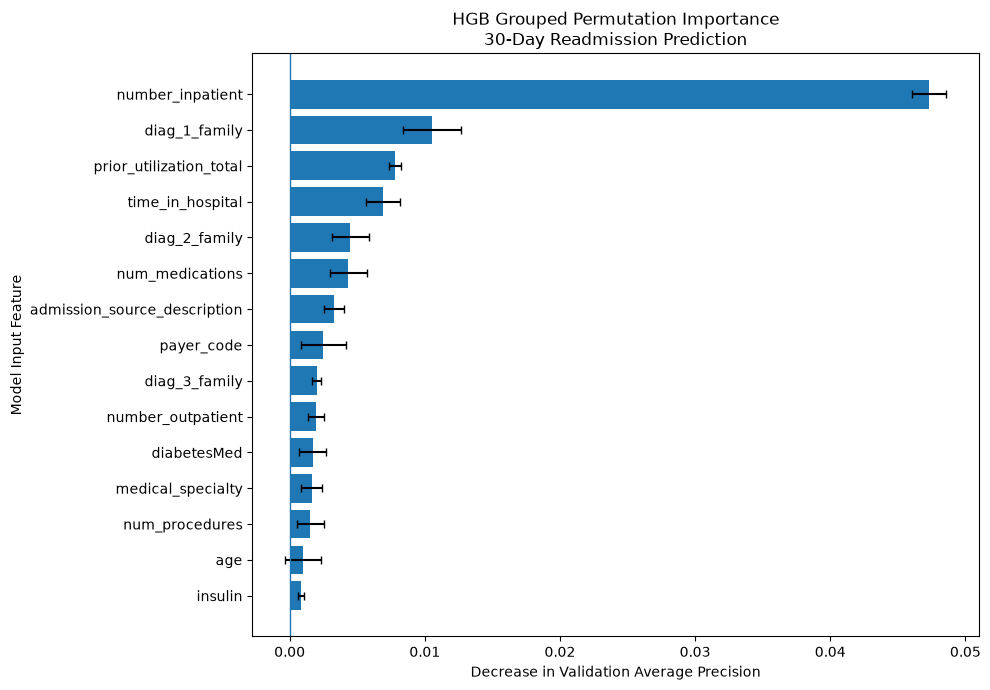

Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_grouped_permutation_importance.png

✓ Top 15 grouped permutation importances visualized.
✓ Error bars represent ±1 standard deviation.
✓ Figure generated from validation analysis only.


In [54]:
# Visualize strongest grouped permutation importances

TOP_N_PLOT = 15

importance_plot_df = (
    grouped_permutation_importance_df.head(TOP_N_PLOT)
    .sort_values(
        "importance_mean",
        ascending=True,
    )
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    importance_plot_df["feature"],
    importance_plot_df["importance_mean"],
    xerr=importance_plot_df["importance_std"],
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title("HGB Grouped Permutation Importance\n" "30-Day Readmission Prediction")

ax.set_xlabel("Decrease in Validation Average Precision")

ax.set_ylabel("Model Input Feature")

fig.tight_layout()

IMPORTANCE_FIGURE_PATH = REPORTS_DIR / "hgb_grouped_permutation_importance.png"

fig.savefig(
    IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

assert IMPORTANCE_FIGURE_PATH.exists()

print(f"Figure saved: " f"{IMPORTANCE_FIGURE_PATH}")

print("\n✓ Top 15 grouped permutation importances visualized.")
print("✓ Error bars represent ±1 standard deviation.")
print("✓ Figure generated from validation analysis only.")

### Prior Healthcare Utilization as a Predictive Concept

Because several utilization variables contain overlapping representations, concept-level permutation importance provides a complementary view of the model's dependence on prior healthcare use.

The figure below jointly evaluates related utilization representations. In particular, the `all_prior_utilization_history` group captures inpatient, outpatient, emergency, aggregate, and corresponding log-transformed utilization measures.

This analysis demonstrates predictive dependence within the fitted model and does not establish that prior utilization causes subsequent readmission.

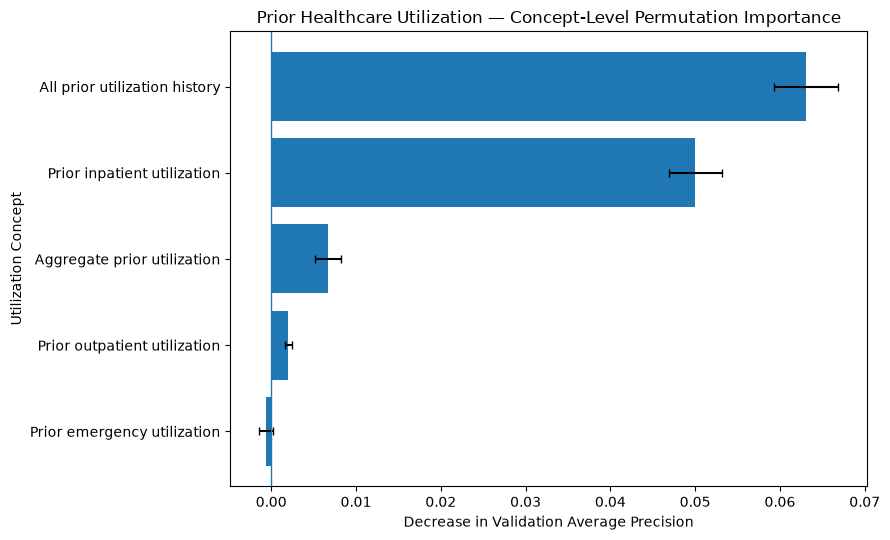

Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_utilization_concept_importance.png

✓ Utilization concept importance visualized.
✓ Error bars represent ±1 standard deviation.
✓ Negative importance is retained rather than hidden.
✓ Figure generated from validation analysis only.


In [55]:
# Visualize utilization concept-level permutation importance

concept_plot_df = utilization_concept_importance_df.sort_values(
    "importance_mean",
    ascending=True,
).copy()

# Improve labels for reporting.
concept_label_map = {
    "all_prior_utilization_history": "All prior utilization history",
    "prior_inpatient_utilization": "Prior inpatient utilization",
    "aggregate_prior_utilization": "Aggregate prior utilization",
    "prior_outpatient_utilization": "Prior outpatient utilization",
    "prior_emergency_utilization": "Prior emergency utilization",
}

concept_plot_df["display_label"] = concept_plot_df["concept"].map(concept_label_map)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    concept_plot_df["display_label"],
    concept_plot_df["importance_mean"],
    xerr=concept_plot_df["importance_std"],
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.set_title("Prior Healthcare Utilization — " "Concept-Level Permutation Importance")

ax.set_xlabel("Decrease in Validation Average Precision")

ax.set_ylabel("Utilization Concept")

fig.tight_layout()

UTILIZATION_FIGURE_PATH = REPORTS_DIR / "hgb_utilization_concept_importance.png"

fig.savefig(
    UTILIZATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

assert UTILIZATION_FIGURE_PATH.exists()

print(f"Figure saved: " f"{UTILIZATION_FIGURE_PATH}")

print("\n✓ Utilization concept importance visualized.")
print("✓ Error bars represent ±1 standard deviation.")
print("✓ Negative importance is retained rather than hidden.")
print("✓ Figure generated from validation analysis only.")

## M6O — Model Optimization and Interpretation Conclusions

Notebook 06 extended the baseline modeling workflow through controlled model optimization, alternative model-family evaluation, operating-threshold analysis, and validation-based model interpretation.

### Random-Forest Optimization

Controlled random-forest tuning produced only modest improvements over the baseline random forest. The selected optimized random forest achieved a held-out ROC-AUC of approximately **0.6494** and average precision of **0.2033**. At its validation-selected screening threshold of **0.43**, the model emphasized sensitivity over specificity.

The limited discrimination improvement suggests that additional random-forest tuning alone is unlikely to overcome the predictive limitations of the available encounter-level features.

### Histogram Gradient Boosting

Histogram gradient boosting provided stronger development-stage validation performance than the optimized random forest. HGB Candidate 3 achieved:

- ROC-AUC: **0.6343**
- Average precision: **0.1907**
- Brier score: **0.0953**

A refined validation-only threshold search identified **0.089** as the highest threshold preserving the random forest's reference screening sensitivity. At this operating point, HGB achieved:

- Sensitivity: **0.7397**
- Specificity: **0.4401**
- Precision: **0.1406**
- Balanced accuracy: **0.5899**
- F1 score: **0.2363**

At comparable sensitivity, HGB therefore improved specificity, precision, balanced accuracy, and F1 relative to the optimized random forest.

HGB Candidate 3 is consequently retained as the **preferred development model**.

### Predictive Interpretation

Grouped permutation importance identified **prior healthcare-utilization history** as the strongest predictive concept in the HGB model. Joint disruption of all prior-utilization representations reduced validation average precision by approximately **0.063**.

Prior inpatient utilization was particularly influential, producing an average decrease of approximately **0.050** when its raw and log-transformed representations were jointly permuted.

Additional predictive information was associated with diagnosis families, time in hospital, medication burden, admission context, and other encounter characteristics.

These findings describe the fitted model's predictive dependence and must not be interpreted as causal relationships.

### Evaluation Boundary

The original held-out test partition was evaluated only after the optimized random-forest configuration and threshold had been locked. Subsequent HGB model-family exploration occurred after that test result had already been observed.

Accordingly, HGB performance is reported as **development-stage validation evidence**, not as a new independent held-out performance estimate. A new untouched sample, external dataset, or appropriately designed confirmation procedure would be required for a new independent generalization claim.

### Overall Finding

The optimization workflow produced incremental rather than dramatic discrimination improvements. This is consistent with the difficulty of predicting 30-day hospital readmission from the available historical encounter data.

The principal modeling insight is therefore not an artificially high performance claim, but a reproducible and leakage-conscious demonstration that prior utilization—especially prior inpatient utilization—contains substantial predictive information for early readmission risk, with additional signal contributed by diagnosis and encounter complexity.

In [56]:
# Final Notebook 06 artifact audit

notebook06_artifacts = {
    "optimized_random_forest": MODELS_DIR / "random_forest_optimized.joblib",
    "hgb_development_model": MODELS_DIR / "hist_gradient_boosting_development.joblib",
    "optimization_metadata": MODELS_DIR / "notebook06_optimization_metadata.json",
    "grouped_permutation_importance": REPORTS_DIR
    / "hgb_grouped_permutation_importance.csv",
    "utilization_concept_importance": REPORTS_DIR
    / "hgb_utilization_concept_importance.csv",
    "grouped_importance_figure": REPORTS_DIR / "hgb_grouped_permutation_importance.png",
    "utilization_concept_figure": REPORTS_DIR
    / "hgb_utilization_concept_importance.png",
}

print("NOTEBOOK 06 FINAL ARTIFACT AUDIT")
print("=" * 88)

all_artifacts_present = True

for artifact_name, artifact_path in notebook06_artifacts.items():

    exists = artifact_path.exists()

    all_artifacts_present &= exists

    status = "✓" if exists else "✗"

    print(f"{status} " f"{artifact_name:<32} " f"{artifact_path}")

assert all_artifacts_present

print("\n" + "=" * 88)
print("✓ All Notebook 06 artifacts are present.")
print("✓ Optimized RF test result remains documented.")
print("✓ HGB remains explicitly development-stage.")
print("✓ Interpretation outputs are reproducible.")
print("✓ Notebook 06 modeling workflow complete.")

NOTEBOOK 06 FINAL ARTIFACT AUDIT
✓ optimized_random_forest          c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\random_forest_optimized.joblib
✓ hgb_development_model            c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\hist_gradient_boosting_development.joblib
✓ optimization_metadata            c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\notebook06_optimization_metadata.json
✓ grouped_permutation_importance   c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_grouped_permutation_importance.csv
✓ utilization_concept_importance   c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_utilization_concept_importance.csv
✓ grouped_importance_figure        c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_grouped_permutation_importance.png
✓ utilization_concept_figure       c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\hgb_uti